# PersuasionForGood Knowledge Graph Analysis

This notebook analyzes the [PersuasionForGood corpus](https://convokit.cornell.edu/documentation/persuasionforgood.html) 
— a dataset of real-world charity donation conversations — using knowledge graph extraction and statistical analysis 
to understand what conversational strategies lead to successful persuasion.


## Output files produced
| HTML file | Section | Description |
|---|---|---|
| `knowledge_graph_comparison.html` | Aggregate Knowledge Graphs | Side-by-side interactive graph: succeeded vs failed |
| `conversation_arc.html` | Conversation Arc | When emotional vs factual concepts first appear across the conversation |
| `donor_authenticity.html` | Donor Authenticity | How the persuader's own donation status affects concept usage |
| `stc_betweenness_scatter.html` | Betweenness Centrality | Save The Children node centrality vs donation amount |
| `logistic_regression.html` | Logistic Regression | Feature importance for predicting persuasion success |


## 1. Setup
Downloads the PersuasionForGood corpus via ConvoKit (cached after first run). 
Set your Anthropic API key below before running the knowledge graph extraction cells.


In [3]:
from convokit import Corpus, download

corpus = Corpus(filename=download("persuasionforgood-corpus"))

Dataset already exists at /Users/marissabenz/.convokit/saved-corpora/persuasionforgood-corpus


In [4]:
import os
os.environ["ANTHROPIC_API_KEY"] = "YOUR_API_KEY_HERE"


## 2. Data Exploration
Print sample conversations and plot the distribution of `donation_ee` 
(the amount donated by the person being persuaded). 


In [5]:
# Print 3 sample conversations
convos = list(corpus.iter_conversations())

for convo in convos[:3]:
    print(f"=== Conversation ID: {convo.id} ===")
    meta = convo.meta
    print(f"  donation_ee: {meta.get('donation_ee', 'N/A')}")
    print(f"  persuasion_strategy: {meta.get('persuasion_strategy', 'N/A')}")
    print()
    for utt in convo.iter_utterances():
        speaker = utt.speaker.id
        text = utt.text[:200].replace('\n', ' ') if utt.text else ''
        print(f"  [{speaker}]: {text}")
    print()

=== Conversation ID: 0 ===
  donation_ee: 0.0
  persuasion_strategy: N/A

  [A3A07QA5U733HQ]: Good morning. How are you doing today?
  [A25L985XCNESXE]: Hi. I am doing good. How about you?
  [A3A07QA5U733HQ]: I'm doing pretty good for a Tuesday morning. 
  [A25L985XCNESXE]: Haha. Same here, but it really feels like a Monday.
  [A3A07QA5U733HQ]: Ugh yes it does!
  [A25L985XCNESXE]: I can not believe how warm it is already.
  [A3A07QA5U733HQ]: Where are you from? 
  [A25L985XCNESXE]: I am from the Midwest. What about you?
  [A3A07QA5U733HQ]: I'm from the South East. It's always warm here. 
  [A25L985XCNESXE]: Oh, yep. You are definitely in for warm weather, which is great as far as I am concerned.
  [A3A07QA5U733HQ]: We're about to get hit by a tropical storm.
  [A25L985XCNESXE]: I heard that some bad weather was going to be coming. I hope it is not too severe.
  [A3A07QA5U733HQ]: Me too. It's just part of living on the Gulf. You have to be prepared for it.
  [A25L985XCNESXE]: Yes, I am 

donation_ee == 0  (gave nothing):   472
donation_ee  > 0  (gave something): 545


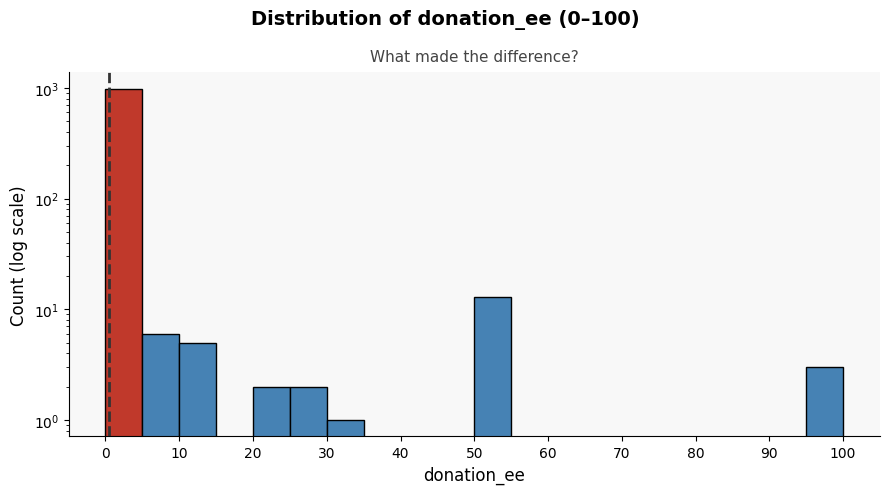

In [6]:
import matplotlib.pyplot as plt
import numpy as np

donation_vals = [c.meta.get('donation_ee') for c in corpus.iter_conversations()
                 if c.meta.get('donation_ee') is not None]

arr = np.array(donation_vals)
zoomed = arr[arr <= 100]

n_zero    = (arr == 0).sum()
n_nonzero = (arr  > 0).sum()

print(f"donation_ee == 0  (gave nothing):   {n_zero}")
print(f"donation_ee  > 0  (gave something): {n_nonzero}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor('#f8f8f8')

_, _, patches = ax.hist(zoomed, bins=range(0, 101, 5), edgecolor='black', color='steelblue', zorder=2)
patches[0].set_facecolor('#c0392b')

ax.set_yscale('log')

ax.axvline(x=0.5, color='#333333', linestyle='--', linewidth=2, zorder=5)

ax.set_xlabel('donation_ee', fontsize=12)
ax.set_ylabel('Count (log scale)', fontsize=12)
ax.set_xticks(range(0, 101, 10))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Distribution of donation_ee (0–100)', fontsize=14, fontweight='bold')
ax.set_title('What made the difference?', fontsize=11, color='#444444', pad=8)

plt.tight_layout()
plt.show()

In [7]:
arr = np.array(donation_vals)
print(f"N:          {len(arr)}")
print(f"Mean:       {arr.mean():.4f}")
print(f"Median:     {np.median(arr):.4f}")
print(f"Std dev:    {arr.std():.4f}")
print(f"Min / Max:  {arr.min()} / {arr.max()}")
print(f"% zeros:    {(arr == 0).mean() * 100:.1f}%")

N:          1017
Mean:       2.1707
Median:     0.0500
Std dev:    23.2938
Min / Max:  0.0 / 700.0
% zeros:    46.4%


## 3. Knowledge Graph Extraction (LLM)
Uses LangChain to extract subject–relation–object triples from each persuader's utterances, 
building a per-conversation knowledge graph. Results are saved to `graph_records.json` so this 
step only needs to run once — subsequent cells load from that file.

> **Requires:** `ANTHROPIC_API_KEY` set above. Extraction can take several minutes for the full corpus.


In [8]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "langchain-anthropic", "langchain-experimental", "langchain-core"])

from langchain_anthropic import ChatAnthropic
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_core.documents import Document

llm = ChatAnthropic(model="claude-haiku-4-5", temperature=0)
transformer = LLMGraphTransformer(llm=llm)

convos = list(corpus.iter_conversations())[:10]
lc_graph_records = []

for convo in convos:
    persuader_turns = [
        utt.text for utt in convo.iter_utterances()
        if utt.meta.get("role") == 0 and utt.text
    ]
    if not persuader_turns:
        continue

    text = " ".join(persuader_turns)
    graph_doc = transformer.convert_to_graph_documents([Document(page_content=text)])[0]

    nodes = [n.id for n in graph_doc.nodes]
    edges = [(r.source.id, r.type, r.target.id) for r in graph_doc.relationships]

    lc_graph_records.append({
        "convo_id":    convo.id,
        "nodes":       nodes,
        "edges":       edges,
        "donation_ee": convo.meta.get("donation_ee"),
        "donation_er": convo.meta.get("donation_er"),
    })

for r in lc_graph_records:
    print(f"── Convo {r['convo_id']} ──")
    print(f"  donation_ee: {r['donation_ee']}  |  donation_er: {r['donation_er']}")
    print(f"  Nodes ({len(r['nodes'])}): {r['nodes']}")
    print(f"  Edges ({len(r['edges'])}):")
    for src, rel, tgt in r["edges"]:
        print(f"    {src} --[{rel}]--> {tgt}")
    print()



[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/2763384233.py:6: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.graph_transformers import LLMGraphTransformer


── Convo 0 ──
  donation_ee: 0.0  |  donation_er: 0.0
  Nodes (4): ['Save The Children', 'South East', 'Gulf', 'Tropical Storm']
  Edges (3):
    Save The Children --[HELPS]--> Children In Need
    South East --[AFFECTED_BY]--> Tropical Storm
    Gulf --[AFFECTED_BY]--> Tropical Storm

── Convo 21 ──
  donation_ee: 2.0  |  donation_er: 0.0
  Nodes (7): ['Save The Children', 'Children In Need', 'Developing Countries', 'Child Sponsorship Program', 'Fundraising Events', 'Advocacy', 'Donations']
  Edges (6):
    Save The Children --[SUPPORTS]--> Children In Need
    Save The Children --[OPERATES_IN]--> Developing Countries
    Save The Children --[OFFERS]--> Child Sponsorship Program
    Save The Children --[OFFERS]--> Fundraising Events
    Save The Children --[OFFERS]--> Advocacy
    Save The Children --[ACCEPTS]--> Donations

── Convo 41 ──
  donation_ee: 0.05  |  donation_er: 0.05
  Nodes (3): ['Save The Children', 'Friend', 'Speaker']
  Edges (3):
    Friend --[CONVINCED]--> Speaker
 

In [9]:
import sys, subprocess, json, os
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "langchain-anthropic", "langchain-experimental",
                       "langchain-core", "tqdm"])

from langchain_anthropic import ChatAnthropic
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_core.documents import Document
from tqdm.auto import tqdm

SAVE_PATH = "graph_records.json"

# Resume from checkpoint if the file already exists
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH) as f:
        all_records = json.load(f)
    done_ids = {r["convo_id"] for r in all_records}
    print(f"Resuming — {len(done_ids)} conversations already saved.")
else:
    all_records = []
    done_ids = set()

llm = ChatAnthropic(model="claude-haiku-4-5", temperature=0)
transformer = LLMGraphTransformer(llm=llm)

all_convos = list(corpus.iter_conversations())
todo = [c for c in all_convos if c.id not in done_ids]
print(f"Conversations to process: {len(todo)} / {len(all_convos)}")

for convo in tqdm(todo, desc="Building graphs"):
    try:
        persuader_turns = [
            utt.text for utt in convo.iter_utterances()
            if utt.meta.get("role") == 0 and utt.text
        ]
        if not persuader_turns:
            continue

        text = " ".join(persuader_turns)
        graph_doc = transformer.convert_to_graph_documents(
            [Document(page_content=text)]
        )[0]

        nodes = [n.id for n in graph_doc.nodes]
        edges = [(r.source.id, r.type, r.target.id) for r in graph_doc.relationships]

        record = {
            "convo_id":    convo.id,
            "nodes":       nodes,
            "edges":       edges,
            "donation_ee": convo.meta.get("donation_ee"),
            "donation_er": convo.meta.get("donation_er"),
        }
        all_records.append(record)

        # Save after every conversation so progress survives a restart
        with open(SAVE_PATH, "w") as f:
            json.dump(all_records, f)

    except Exception as e:
        tqdm.write(f"  ✗ convo {convo.id}: {e}")
        continue

print(f"\nDone. {len(all_records)} records saved to {SAVE_PATH}.")



[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


Resuming — 1017 conversations already saved.
Conversations to process: 0 / 1017


Building graphs: 0it [00:00, ?it/s]


Done. 1017 records saved to graph_records.json.


## 4. Success / Failure Split
Counts how many conversations resulted in a donation (`donation_ee > 0`) vs did not. 
This defines the two groups used throughout the analysis.


In [10]:
total = len(list(corpus.iter_conversations()))
failed = sum(1 for c in corpus.iter_conversations() if c.meta.get("donation_ee") == 0)
succeeded = total - failed
print(f"Total: {total}")
print(f"Failed (donation=0): {failed} ({failed/total*100:.1f}%)")
print(f"Succeeded (donation>0): {succeeded} ({succeeded/total*100:.1f}%)")

Total: 1017
Failed (donation=0): 472 (46.4%)
Succeeded (donation>0): 545 (53.6%)


## 5. Graph Metric Computation
Loads `graph_records.json` and computes per-conversation graph metrics using NetworkX: 
node count, edge count, edge density, average clustering coefficient, and whether a personal-topic node is present. 
Results are stored in `df_metrics` for downstream analysis.


In [11]:
import json, subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])

import networkx as nx
import pandas as pd

PERSONAL_WORDS = {"personal", "story", "family", "friend", "child",
                  "children", "i", "my", "me"}

def personal_hit(nodes):
    for n in nodes:
        if any(w in n.lower().split() for w in PERSONAL_WORDS):
            return True
    return False

with open("graph_records.json") as f:
    records = json.load(f)

rows = []
for r in records:
    nodes = r["nodes"]
    edges = r["edges"]

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from([(s, t) for s, _, t in edges])

    n = G.number_of_nodes()
    e = G.number_of_edges()
    max_edges = n * (n - 1) if n > 1 else 1
    density = e / max_edges

    # clustering on undirected view
    U = G.to_undirected()
    avg_clust = nx.average_clustering(U) if n > 1 else 0.0

    rows.append({
        "convo_id":                    r["convo_id"],
        "donation_ee":                 r["donation_ee"],
        "donation_er":                 r["donation_er"],
        "node_count":                  n,
        "edge_count":                  e,
        "edge_density":                density,
        "avg_clustering":              avg_clust,
        "has_personal_node":           personal_hit(nodes),
    })

df_metrics = pd.DataFrame(rows)

# ── Correlation table: all numeric metrics vs donation_ee ──
metric_cols = ["node_count", "edge_count", "edge_density",
               "avg_clustering", "has_personal_node"]
numeric_df = df_metrics[metric_cols + ["donation_ee"]].copy()
numeric_df["has_personal_node"] = numeric_df["has_personal_node"].astype(float)

corr = numeric_df.corr()[["donation_ee"]].rename(
    columns={"donation_ee": "corr_with_donation_ee"}
).drop("donation_ee")

print("=== Correlation with donation_ee ===")
print(corr.round(4).to_string())
print()
print("=== df_metrics — first 5 rows ===")
print(df_metrics.head().to_string(index=False))



[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


=== Correlation with donation_ee ===
                   corr_with_donation_ee
node_count                       -0.0365
edge_count                       -0.0356
edge_density                      0.0378
avg_clustering                   -0.0051
has_personal_node                 0.0094

=== df_metrics — first 5 rows ===
convo_id  donation_ee  donation_er  node_count  edge_count  edge_density  avg_clustering  has_personal_node
       0         0.00         0.00           5           3      0.150000             0.0               True
      21         2.00         0.00           8           7      0.125000             0.0               True
      41         0.05         0.05           2           1      0.500000             0.0               True
      61         0.00         0.00          10           9      0.100000             0.0               True
      82         1.00         0.00          14          13      0.071429             0.0               True


## 6. Statistical Comparison: Graph Metrics
Compares graph metrics between succeeded and failed conversations using Welch's t-test. 
Side-by-side boxplots visualize the distributions. Significant differences are marked with `*`.


succeeded (donation_ee > 0): n=545
failed    (donation_ee == 0): n=472

=== Group means + Welch t-test ===
                   mean_succeeded  mean_failed    diff  p_value significant
metric                                                                     
node_count                 6.4275       6.4428 -0.0153   0.9440            
edge_count                 5.2972       5.2415  0.0557   0.7947            
edge_density               0.1927       0.1943 -0.0016   0.8324            
avg_clustering             0.0373       0.0318  0.0055   0.4929            
has_personal_node          0.9633       0.9682 -0.0049   0.6667            



/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/4168106400.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/4168106400.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


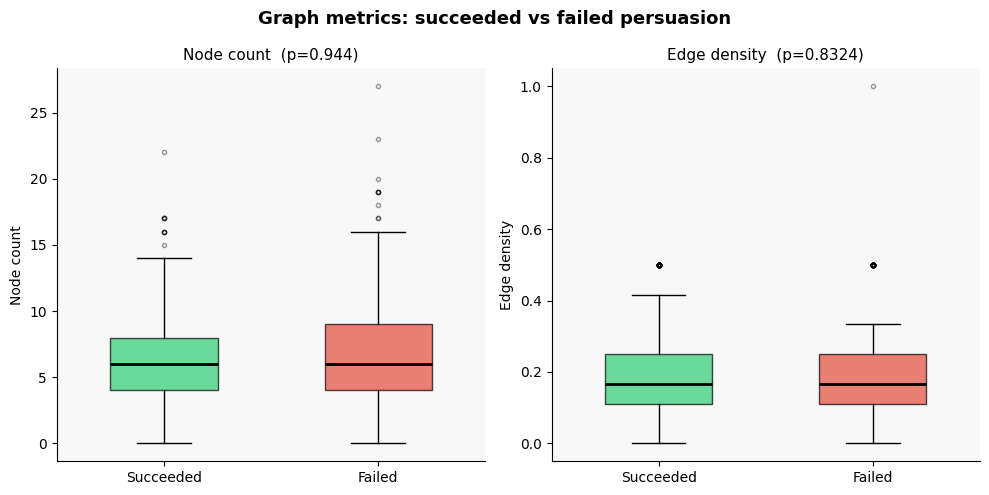

In [12]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

metric_cols = ["node_count", "edge_count", "edge_density",
               "avg_clustering", "has_personal_node"]

succeeded = df_metrics[df_metrics["donation_ee"] > 0].copy()
failed    = df_metrics[df_metrics["donation_ee"] == 0].copy()

# ── 1. Mean comparison + t-test ──────────────────────────────────────────────
rows = []
for col in metric_cols:
    a = succeeded[col].astype(float)
    b = failed[col].astype(float)
    t, p = stats.ttest_ind(a, b, equal_var=False)  # Welch's t-test
    rows.append({
        "metric":           col,
        "mean_succeeded":   round(a.mean(), 4),
        "mean_failed":      round(b.mean(), 4),
        "diff":             round(a.mean() - b.mean(), 4),
        "p_value":          round(p, 4),
        "significant":      "✓" if p < 0.05 else "",
    })

import pandas as pd
df_ttest = pd.DataFrame(rows).set_index("metric")
print(f"succeeded (donation_ee > 0): n={len(succeeded)}")
print(f"failed    (donation_ee == 0): n={len(failed)}")
print()
print("=== Group means + Welch t-test ===")
print(df_ttest.to_string())
print()

# ── 2. Side-by-side boxplots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Graph metrics: succeeded vs failed persuasion", fontsize=13, fontweight="bold")

plot_specs = [
    ("node_count",   "Node count"),
    ("edge_density", "Edge density"),
]

colors = {"Succeeded": "#2ecc71", "Failed": "#e74c3c"}

for ax, (col, label) in zip(axes, plot_specs):
    data_s = succeeded[col].astype(float).values
    data_f = failed[col].astype(float).values

    bp = ax.boxplot(
        [data_s, data_f],
        labels=["Succeeded", "Failed"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        widths=0.5,
    )
    for patch, key in zip(bp["boxes"], ["Succeeded", "Failed"]):
        patch.set_facecolor(colors[key])
        patch.set_alpha(0.7)

    # annotate p-value
    p = df_ttest.loc[col, "p_value"]
    sig = " *" if p < 0.05 else ""
    ax.set_title(f"{label}  (p={p}{sig})", fontsize=11)
    ax.set_ylabel(label)
    ax.set_facecolor("#f8f8f8")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 7. K-Means Clustering
Clusters conversations by their graph metrics (standardized) to find natural groupings. 
Cluster membership is then compared to persuasion outcome to see if any cluster is predictive of success.


=== Average donation_ee by cluster ===
cluster_label
Medium         3.0341
Sparse         1.9918
Large-dense    1.3506
Small-dense    1.0550

=== Cluster means (graph metrics) ===
               node_count  edge_count  edge_density  avg_clustering
cluster_label                                                      
Large-dense         5.149       5.021         0.264           0.532
Medium              5.302       4.000         0.174           0.004
Small-dense        10.521       9.305         0.099           0.027
Sparse              2.665       1.699         0.396           0.000



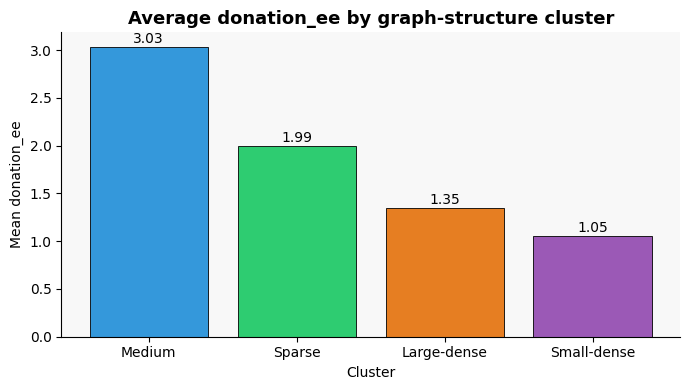

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cluster_features = ["node_count", "edge_count", "edge_density", "avg_clustering"]

X = df_metrics[cluster_features].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_metrics["cluster"] = km.fit_predict(X_scaled)

# Descriptive labels: rank clusters by mean node_count
cluster_means = df_metrics.groupby("cluster")[cluster_features].mean()
rank_order = cluster_means["node_count"].argsort()          # low → high node count
labels = ["Sparse", "Small-dense", "Medium", "Large-dense"]
label_map = {int(cid): labels[rank] for rank, cid in enumerate(rank_order.index)}
df_metrics["cluster_label"] = df_metrics["cluster"].map(label_map)

# Average donation_ee per cluster
avg_donation = (df_metrics.groupby("cluster_label")["donation_ee"]
                .mean().sort_values(ascending=False).round(4))
print("=== Average donation_ee by cluster ===")
print(avg_donation.to_string())
print()
print("=== Cluster means (graph metrics) ===")
print(df_metrics.groupby("cluster_label")[cluster_features]
      .mean().round(3).to_string())
print()

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]
bars = ax.bar(avg_donation.index, avg_donation.values,
              color=colors[:len(avg_donation)], edgecolor="black", linewidth=0.6)

for bar, val in zip(bars, avg_donation.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average donation_ee by graph-structure cluster", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean donation_ee")
ax.set_facecolor("#f8f8f8")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Text Feature Analysis
Extracts surface-level text features from each persuader's utterances: word count, question count, 
and use of first-person (`I/my`), second-person (`you/your`), and monetary language (`$`/dollar). 
Computes Pearson correlations with `donation_ee` and visualizes distributions by group.


=== Full correlation table vs donation_ee ===
                      corr_with_donation_ee
mentions_amount                      0.0442
edge_density                         0.0378
uses_first_person                    0.0203
has_personal_node                    0.0094
question_count                       0.0068
uses_second_person                   0.0050
avg_clustering                      -0.0051
persuader_word_count                -0.0247
edge_count                          -0.0356
node_count                          -0.0365



/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/1874819027.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/1874819027.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/1874819027.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/j0/9ww0f_8d4_dfkfbfdkbd2bhm0000gn/T/ipykernel_967/1874819027.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotli

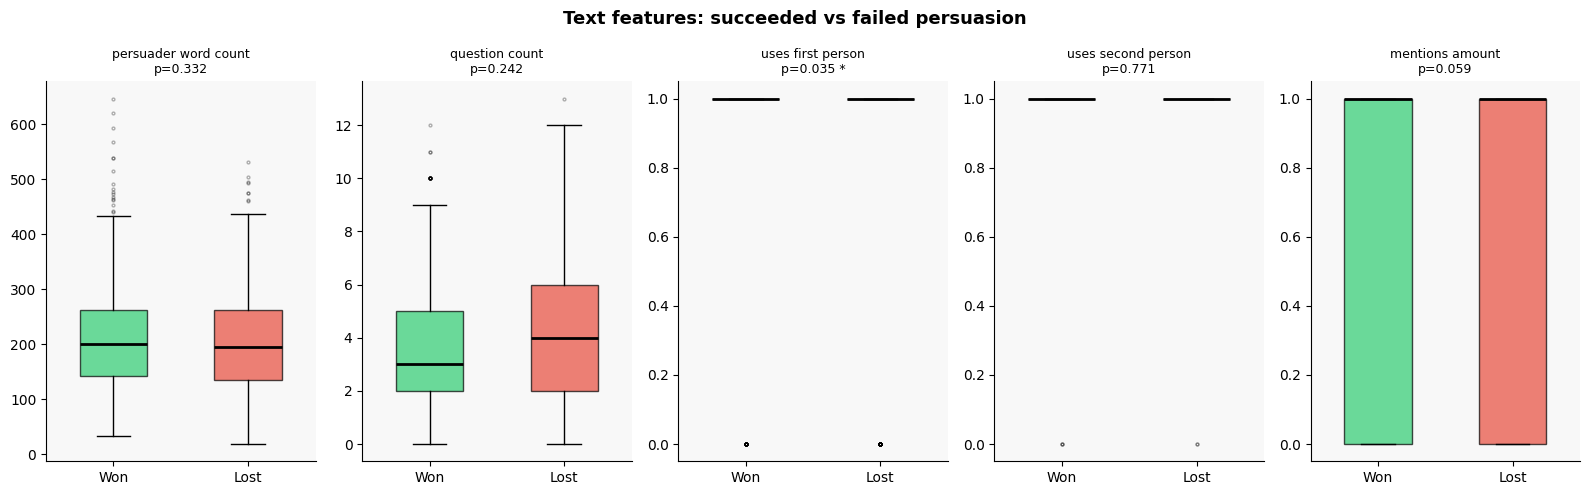

In [14]:
import re
import matplotlib.pyplot as plt
import pandas as pd

# Build a convo_id → persuader text lookup from the live corpus
text_lookup = {}
for convo in corpus.iter_conversations():
    turns = [utt.text or "" for utt in convo.iter_utterances()
             if utt.meta.get("role") == 0]
    text_lookup[convo.id] = " ".join(turns)

def text_features(text):
    t = text or ""
    return {
        "persuader_word_count":  len(t.split()),
        "question_count":        t.count("?"),
        "uses_first_person":     bool(re.search(r"\b(i|my)\b", t, re.I)),
        "uses_second_person":    bool(re.search(r"\b(you|your)\b", t, re.I)),
        "mentions_amount":       bool(re.search(r"\$|\bdollar", t, re.I)),
    }

feat_df = pd.DataFrame(
    [{"convo_id": cid, **text_features(txt)} for cid, txt in text_lookup.items()]
)
df_metrics = df_metrics.merge(feat_df, on="convo_id", how="left")

# ── Correlation table: all features vs donation_ee ──────────────────────────
all_metric_cols = ["node_count", "edge_count", "edge_density", "avg_clustering",
                   "has_personal_node", "persuader_word_count", "question_count",
                   "uses_first_person", "uses_second_person", "mentions_amount"]

corr_df = (df_metrics[all_metric_cols + ["donation_ee"]]
           .astype(float)
           .corr()[["donation_ee"]]
           .drop("donation_ee")
           .rename(columns={"donation_ee": "corr_with_donation_ee"})
           .sort_values("corr_with_donation_ee", ascending=False))

print("=== Full correlation table vs donation_ee ===")
print(corr_df.round(4).to_string())
print()

# ── Boxplots: text features for succeeded vs failed ─────────────────────────
text_cols = ["persuader_word_count", "question_count",
             "uses_first_person", "uses_second_person", "mentions_amount"]

succeeded = df_metrics[df_metrics["donation_ee"] > 0]
failed    = df_metrics[df_metrics["donation_ee"] == 0]

from scipy import stats

fig, axes = plt.subplots(1, len(text_cols), figsize=(16, 5))
fig.suptitle("Text features: succeeded vs failed persuasion",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, text_cols):
    a = succeeded[col].astype(float)
    b = failed[col].astype(float)
    _, p = stats.ttest_ind(a, b, equal_var=False)

    bp = ax.boxplot(
        [a.values, b.values],
        labels=["Won", "Lost"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markersize=2, alpha=0.3),
        widths=0.5,
    )
    for patch, color in zip(bp["boxes"], ["#2ecc71", "#e74c3c"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    sig = " *" if p < 0.05 else ""
    ax.set_title(f"{col.replace('_', ' ')}\np={p:.3f}{sig}", fontsize=9)
    ax.set_facecolor("#f8f8f8")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 9. Non-Parametric Robustness Check
Because `uses_first_person` is binary and the Pearson/t-test assumptions may not hold, 
this section re-tests the first-person finding using Spearman correlation and the Mann-Whitney U test. 
Both are assumption-free with respect to normality.


In [ ]:
# ── Non-parametric robustness check for uses_first_person ─────────────────────
# uses_first_person is binary, so Pearson/t-test assumptions are not ideal.
# Spearman correlation and Mann-Whitney U do not assume normality or continuity.

from scipy import stats

fp  = df_metrics["uses_first_person"].astype(float)
dee = df_metrics["donation_ee"].astype(float)

# 1. Spearman correlation
rho, p_spearman = stats.spearmanr(fp, dee)
print("=== Spearman correlation: uses_first_person vs donation_ee ===")
print(f"  ρ = {rho:.4f},  p = {p_spearman:.4f}{'  *' if p_spearman < 0.05 else ''}")
print()

# 2. Mann-Whitney U (two-sided)
succeeded_fp = df_metrics.loc[df_metrics["donation_ee"] > 0,  "uses_first_person"].astype(float)
failed_fp    = df_metrics.loc[df_metrics["donation_ee"] == 0, "uses_first_person"].astype(float)

U, p_mw = stats.mannwhitneyu(succeeded_fp, failed_fp, alternative="two-sided")
print("=== Mann-Whitney U: uses_first_person (succeeded vs failed) ===")
print(f"  n_succeeded = {len(succeeded_fp)},  n_failed = {len(failed_fp)}")
print(f"  U = {U:.1f},  p = {p_mw:.4f}{'  *' if p_mw < 0.05 else ''}")
print()

# 3. Proportion sanity check
prop_s = succeeded_fp.mean()
prop_f = failed_fp.mean()
print(f"  Proportion using first-person — succeeded: {prop_s:.3f}, failed: {prop_f:.3f}")


## 10. Network Visualization (PyVis)
Builds an interactive in-notebook visualization of the aggregate knowledge graph using PyVis. 
Node size reflects how often a concept appears across conversations; edge weight reflects co-occurrence frequency.


In [15]:
import json, subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyvis"])

from pyvis.network import Network

EMOTIONAL_WORDS = {
    "personal", "story", "family", "friend", "child", "children",
    "i", "my", "me", "feel", "feeling", "emotion", "love", "heart",
    "sad", "happy", "care", "help", "suffer", "poor", "needy",
    "desperate", "hope", "giving", "save", "life", "need",
    "vulnerable", "impact", "donate", "donation",
}

def node_color(name):
    words = set(name.lower().replace("-", " ").split())
    return "#e74c3c" if words & EMOTIONAL_WORDS else "#3498db"

with open("graph_records.json") as f:
    records = json.load(f)
rec_by_id = {r["convo_id"]: r for r in records}

# Best: highest donation; worst: donation==0 with the most nodes
best_row  = df_metrics.loc[df_metrics["donation_ee"].idxmax()]
zero_rows = df_metrics[(df_metrics["donation_ee"] == 0) & (df_metrics["node_count"] > 2)]
worst_row = zero_rows.loc[zero_rows["node_count"].idxmax()]

PHYSICS_OPTIONS = (
    '{"physics":{"solver":"forceAtlas2Based",'
    '"forceAtlas2Based":{"gravitationalConstant":-60,"centralGravity":0.005,'
    '"springLength":120,"springConstant":0.08},'
    '"stabilization":{"iterations":150,"fit":true},"minVelocity":0.75},'
    '"edges":{"smooth":{"type":"curvedCW","roundness":0.2}}}'
)

def build_network(rec, title):
    net = Network(height="650px", width="100%", directed=True,
                  bgcolor="#f9f9f9", font_color="#222222",
                  notebook=False, cdn_resources="in_line")
    net.heading = title

    node_set = set(rec["nodes"])
    for s, _, t in rec["edges"]:
        node_set.update([s, t])

    for node in node_set:
        color = node_color(node)
        degree = sum(1 for s, _, t in rec["edges"] if s == node or t == node)
        kind = "Personal/Emotional" if color == "#e74c3c" else "Factual/Conceptual"
        net.add_node(
            node, label=node,
            color={"background": color, "border": "#222222",
                   "highlight": {"background": "#f39c12", "border": "#222222"}},
            size=20 + 4 * degree,
            font={"size": 13, "color": "#222222"},
            title=f"<b>{node}</b><br>{kind}",
        )

    for s, rel, t in rec["edges"]:
        net.add_edge(
            s, t,
            label=rel.replace("_", " ").lower(),
            title=rel,
            color={"color": "#888888", "highlight": "#f39c12"},
            arrows="to",
            font={"size": 10, "color": "#555555"},
        )

    net.set_options(PHYSICS_OPTIONS)
    return net

targets = [
    (best_row,  "best_convo.html",  "SUCCEEDED"),
    (worst_row, "worst_convo.html", "FAILED"),
]

for row, filename, label in targets:
    rec = rec_by_id.get(row["convo_id"])
    if not rec:
        print(f"No record for convo {row['convo_id']}")
        continue

    donation = row["donation_ee"]
    title = (f"{label} — donation_ee = {donation} | convo {row['convo_id']} | "
             f"nodes = {row['node_count']} | edges = {row['edge_count']}  "
             f"[Red = personal/emotional  ·  Blue = factual]")

    net = build_network(rec, title)
    try:
        net.write_html(filename)
    except AttributeError:
        net.save_graph(filename)

    print(f"Saved {filename}  "
          f"(donation_ee={donation}, nodes={row['node_count']}, "
          f"edges={row['edge_count']})")

print("\nOpen best_convo.html / worst_convo.html in a browser to explore.")
print("Red = personal/emotional  |  Blue = factual/conceptual")
print("Node size proportional to degree. Hover for details, drag to rearrange.")


Saved best_convo.html  (donation_ee=700.0, nodes=4, edges=3)
Saved worst_convo.html  (donation_ee=0.0, nodes=27, edges=26)

Open best_convo.html / worst_convo.html in a browser to explore.
Red = personal/emotional  |  Blue = factual/conceptual
Node size proportional to degree. Hover for details, drag to rearrange.



[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


## 11. Graph Frequency Analysis
Counts how often each node and edge type appears across succeeded vs failed conversations. 
Bar charts highlight which concepts and relationships are distinctive to each group.


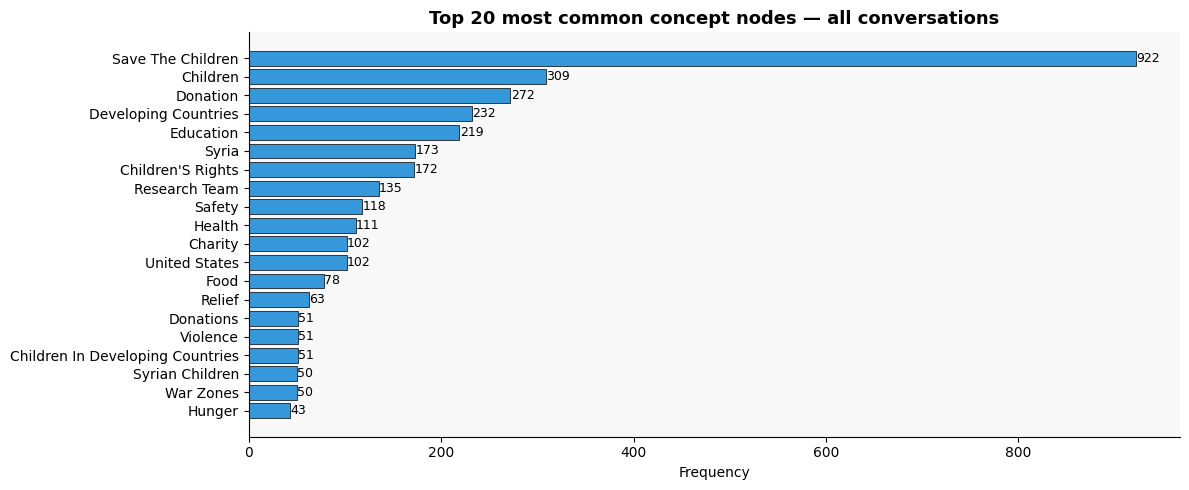

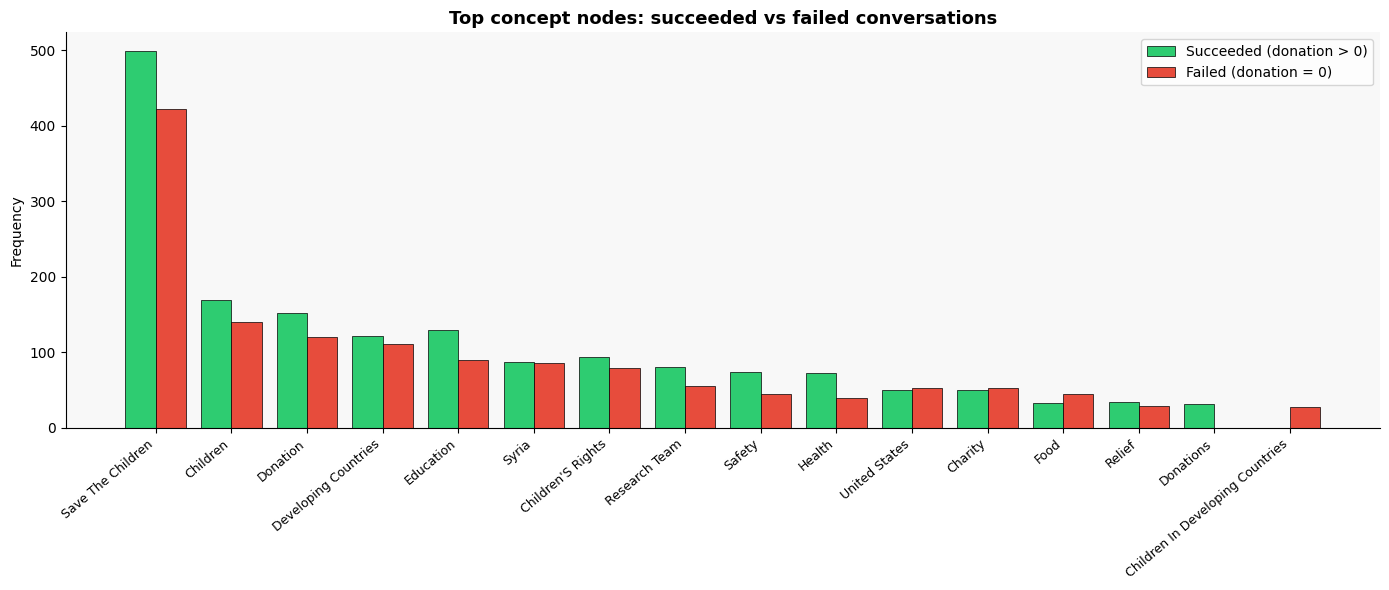

Group sizes — succeeded: 545, failed: 472

=== Normalised node frequency (per conversation) ===
                            node  freq_succeeded  freq_failed  diff_s_minus_f
                       Donations          0.0569       0.0000          0.0569
                          Health          0.1321       0.0826          0.0495
                       Education          0.2367       0.1907          0.0460
                          Safety          0.1358       0.0932          0.0426
                   Research Team          0.1468       0.1165          0.0303
                        Donation          0.2789       0.2542          0.0247
               Save The Children          0.9156       0.8962          0.0194
                        Children          0.3101       0.2966          0.0135
               Children'S Rights          0.1706       0.1674          0.0032
                          Relief          0.0624       0.0614          0.0010
            Developing Countries          0.22

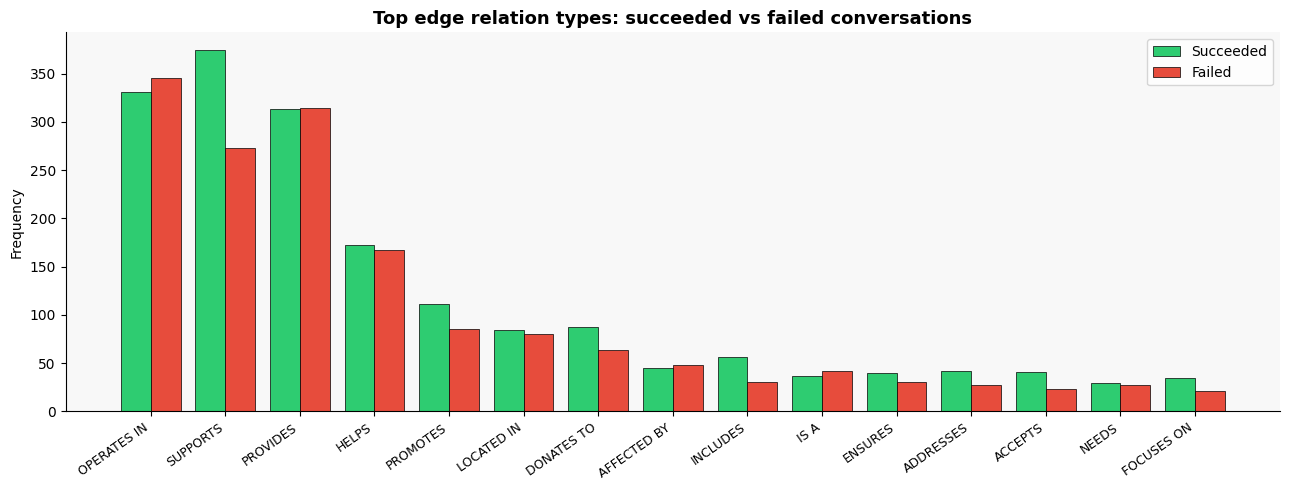


=== Normalised relation frequency (per conversation) ===
   relation  freq_succeeded  freq_failed  diff_s_minus_f
   SUPPORTS          0.6862       0.5784          0.1078
   INCLUDES          0.1028       0.0636          0.0392
    ACCEPTS          0.0752       0.0487          0.0265
 DONATES_TO          0.1596       0.1356          0.0240
   PROMOTES          0.2037       0.1801          0.0236
  ADDRESSES          0.0771       0.0572          0.0199
 FOCUSES_ON          0.0624       0.0445          0.0179
    ENSURES          0.0734       0.0636          0.0098
      NEEDS          0.0532       0.0572         -0.0040
 LOCATED_IN          0.1541       0.1695         -0.0154
AFFECTED_BY          0.0826       0.1017         -0.0191
       IS_A          0.0679       0.0890         -0.0211
      HELPS          0.3156       0.3538         -0.0382
   PROVIDES          0.5743       0.6653         -0.0910
OPERATES_IN          0.6073       0.7309         -0.1236


In [16]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

with open("graph_records.json") as f:
    records = json.load(f)

# Attach donation_ee to each record via df_metrics lookup
donation_map = df_metrics.set_index("convo_id")["donation_ee"].to_dict()
for r in records:
    r["_donation_ee"] = donation_map.get(r["convo_id"], None)

succeeded_recs = [r for r in records if (r["_donation_ee"] or 0) > 0]
failed_recs    = [r for r in records if (r["_donation_ee"] or 0) == 0]

# ── 1. Top 20 nodes across ALL conversations ─────────────────────────────────
all_nodes = Counter(n for r in records for n in r["nodes"])
top20 = all_nodes.most_common(20)
labels20, counts20 = zip(*top20)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(labels20[::-1], counts20[::-1], color="#3498db", edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, counts20[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
ax.set_title("Top 20 most common concept nodes — all conversations",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency")
ax.set_facecolor("#f8f8f8")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# ── 2. Top 15 nodes: succeeded vs failed side-by-side ────────────────────────
def top_n(recs, n=15):
    c = Counter(node for r in recs for node in r["nodes"])
    return dict(c.most_common(n))

top_s = top_n(succeeded_recs)
top_f = top_n(failed_recs)

all_top_labels = sorted(
    set(top_s) | set(top_f),
    key=lambda x: -(top_s.get(x, 0) + top_f.get(x, 0))
)[:20]

x = range(len(all_top_labels))
w = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - w/2 for i in x], [top_s.get(l, 0) for l in all_top_labels],
       width=w, label="Succeeded (donation > 0)", color="#2ecc71",
       edgecolor="black", linewidth=0.5)
ax.bar([i + w/2 for i in x], [top_f.get(l, 0) for l in all_top_labels],
       width=w, label="Failed (donation = 0)", color="#e74c3c",
       edgecolor="black", linewidth=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(all_top_labels, rotation=40, ha="right", fontsize=9)
ax.set_title("Top concept nodes: succeeded vs failed conversations",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Frequency")
ax.legend()
ax.set_facecolor("#f8f8f8")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Normalise by group size so frequencies are comparable
n_s, n_f = len(succeeded_recs), len(failed_recs)
print(f"Group sizes — succeeded: {n_s}, failed: {n_f}")
norm_s = {l: round(top_s.get(l, 0) / n_s, 4) for l in all_top_labels}
norm_f = {l: round(top_f.get(l, 0) / n_f, 4) for l in all_top_labels}
df_node_freq = pd.DataFrame({"node": all_top_labels,
                              "freq_succeeded": [norm_s[l] for l in all_top_labels],
                              "freq_failed":    [norm_f[l] for l in all_top_labels]})
df_node_freq["diff_s_minus_f"] = (df_node_freq["freq_succeeded"]
                                   - df_node_freq["freq_failed"]).round(4)
print("\n=== Normalised node frequency (per conversation) ===")
print(df_node_freq.sort_values("diff_s_minus_f", ascending=False).to_string(index=False))

# ── 3. Most common edge relation types: succeeded vs failed ───────────────────
def rel_counter(recs):
    return Counter(rel for r in recs for _, rel, _ in r["edges"])

rel_s = rel_counter(succeeded_recs)
rel_f = rel_counter(failed_recs)

top_rels = sorted(
    set(list(rel_s) + list(rel_f)),
    key=lambda x: -(rel_s.get(x, 0) + rel_f.get(x, 0))
)[:15]

x = range(len(top_rels))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - w/2 for i in x], [rel_s.get(r, 0) for r in top_rels],
       width=w, label="Succeeded", color="#2ecc71", edgecolor="black", linewidth=0.5)
ax.bar([i + w/2 for i in x], [rel_f.get(r, 0) for r in top_rels],
       width=w, label="Failed", color="#e74c3c", edgecolor="black", linewidth=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels([r.replace("_", " ") for r in top_rels],
                   rotation=35, ha="right", fontsize=9)
ax.set_title("Top edge relation types: succeeded vs failed conversations",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Frequency")
ax.legend()
ax.set_facecolor("#f8f8f8")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Normalised relation table
norm_rs = {r: round(rel_s.get(r, 0) / n_s, 4) for r in top_rels}
norm_rf = {r: round(rel_f.get(r, 0) / n_f, 4) for r in top_rels}
df_rel_freq = pd.DataFrame({"relation": top_rels,
                             "freq_succeeded": [norm_rs[r] for r in top_rels],
                             "freq_failed":    [norm_rf[r] for r in top_rels]})
df_rel_freq["diff_s_minus_f"] = (df_rel_freq["freq_succeeded"]
                                  - df_rel_freq["freq_failed"]).round(4)
print("\n=== Normalised relation frequency (per conversation) ===")
print(df_rel_freq.sort_values("diff_s_minus_f", ascending=False).to_string(index=False))


## 12. Aggregate Knowledge Graph Comparison
Builds separate aggregate knowledge graphs for succeeded and failed conversations, 
keeping only edges that appear in at least 3 conversations. 
Outputs an interactive side-by-side visualization.

**Output:** `knowledge_graph_comparison.html`


In [17]:
import json, sys, subprocess, urllib.request
from collections import Counter
import networkx as nx

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])

# ── Load & split ──────────────────────────────────────────────────────────────
with open("graph_records.json") as f:
    records = json.load(f)

succeeded_recs = [r for r in records if (r.get("donation_ee") or 0) > 0]
failed_recs    = [r for r in records if (r.get("donation_ee") or 0) == 0]

print(f"Succeeded: {len(succeeded_recs)} conversations")
print(f"Failed:    {len(failed_recs)} conversations")

# ── Aggregate graph builder ───────────────────────────────────────────────────
def build_aggregate(recs, min_triple_count=3):
    node_counts = Counter()
    for r in recs:
        for n in set(r["nodes"]):
            node_counts[n] += 1

    edge_counts = Counter()
    for r in recs:
        seen = set()
        for edge in r["edges"]:
            t = (edge[0], edge[1], edge[2])
            if t not in seen:
                edge_counts[t] += 1
                seen.add(t)

    kept_edges = {t: c for t, c in edge_counts.items() if c >= min_triple_count}
    edge_nodes = {n for t in kept_edges for n in (t[0], t[2])}
    kept_nodes = {n: node_counts.get(n, 0) for n in edge_nodes}
    return kept_nodes, kept_edges

# ── Structural stats ──────────────────────────────────────────────────────────
def graph_stats(kept_nodes, kept_edges, label):
    G = nx.DiGraph()
    G.add_nodes_from(kept_nodes.keys())
    for (src, rel, tgt), w in kept_edges.items():
        G.add_edge(src, tgt, relation=rel, weight=w)

    n  = G.number_of_nodes()
    e  = G.number_of_edges()
    max_e     = n * (n - 1) if n > 1 else 1
    density   = e / max_e if max_e > 0 else 0.0
    U         = G.to_undirected()
    avg_clust = nx.average_clustering(U) if n > 1 else 0.0
    avg_deg   = sum(d for _, d in G.degree()) / n if n > 0 else 0.0
    bc        = nx.betweenness_centrality(G, normalized=True) if n > 1 else {}
    top_bc    = sorted(bc.items(), key=lambda x: -x[1])[:5]

    print(f"\n{'━'*60}")
    print(f"  {label}")
    print(f"{'━'*60}")
    print(f"  Nodes in filtered graph : {n}")
    print(f"  Edges (triple ≥ 3)      : {e}")
    print(f"  Graph density           : {density:.4f}")
    print(f"  Average degree          : {avg_deg:.3f}")
    print(f"  Avg clustering coeff    : {avg_clust:.4f}")
    print(f"  Top betweenness centrality:")
    for nd, sc in top_bc:
        print(f"    {sc:.4f}  {nd}")

    return dict(n=n, e=e, density=round(density, 4),
                avg_deg=round(avg_deg, 3), avg_clust=round(avg_clust, 4),
                top_bc=top_bc)

nodes_s, edges_s = build_aggregate(succeeded_recs)
nodes_f, edges_f = build_aggregate(failed_recs)

stats_s = graph_stats(nodes_s, edges_s, "SUCCEEDED (donation_ee > 0)")
stats_f = graph_stats(nodes_f, edges_f, "FAILED    (donation_ee == 0)")

# ── Download vis.js for offline / file:// embedding ──────────────────────────
def _fetch(url):
    with urllib.request.urlopen(url, timeout=30) as r:
        return r.read().decode("utf-8")

_VIS_CSS_FALLBACK = (
    ".vis-network{position:relative;overflow:hidden}"
    ".vis-network canvas{position:absolute;top:0;left:0;touch-action:none}"
    ".vis-tooltip{position:absolute;visibility:hidden;padding:5px;"
    "white-space:nowrap;font-family:verdana;font-size:14px;color:#000;"
    "background-color:#f5f4ed;border-radius:3px;border:1px solid #808074;"
    "box-shadow:3px 3px 10px rgba(0,0,0,.2);pointer-events:none}"
)

print("\nFetching vis.js for inline embedding (run once; saves offline-capable HTML)...")
_vis_js = _fetch("https://unpkg.com/vis-network@9.1.9/dist/vis-network.min.js")
print(f"  vis.js  {len(_vis_js)//1024} KB")

try:
    _vis_css = _fetch("https://unpkg.com/vis-network@9.1.9/dist/vis-network.min.css")
    print(f"  vis.css {len(_vis_css)//1024} KB")
except Exception as _e:
    _vis_css = _VIS_CSS_FALLBACK
    print(f"  vis.css not available ({_e}) — using bundled minimal styles")

# ── Vis.js node / edge serialisers ────────────────────────────────────────────
EMOTIONAL_WORDS = {
    "personal","story","family","friend","child","children","i","my","me",
    "feel","feeling","emotion","love","heart","sad","happy","care","help",
    "suffer","poor","needy","desperate","hope","giving","save","life","need",
    "vulnerable","impact","donate","donation",
}

def node_color(name):
    words = set(name.lower().replace("-", " ").split())
    return "#e74c3c" if words & EMOTIONAL_WORDS else "#3498db"

def to_vis_json(kept_nodes, kept_edges):
    max_nc = max(kept_nodes.values(), default=1)
    max_ec = max(kept_edges.values(), default=1)

    vis_nodes = [
        dict(
            id=nm, label=nm,
            title="<b>" + nm + "</b><br>In " + str(cnt) + " conversations",
            color=dict(background=node_color(nm), border="#333",
                       highlight=dict(background="#f39c12", border="#333")),
            size=round(12 + 28 * (cnt / max_nc), 1),
            font=dict(size=12, color="#111"),
            shape="dot",
        )
        for nm, cnt in kept_nodes.items()
    ]

    vis_edges = []
    for i, ((src, rel, tgt), cnt) in enumerate(kept_edges.items()):
        ed = dict(
            id=i, to=tgt,
            label=rel.replace("_", " ").lower(),
            title=rel + " (" + str(cnt) + " conversations)",
            arrows="to",
            width=round(1 + 4 * (cnt / max_ec), 2),
            color=dict(color="#888", highlight="#f39c12"),
            font=dict(size=9, color="#555", align="middle"),
            smooth=dict(type="curvedCW", roundness=0.2),
        )
        ed["from"] = src
        vis_edges.append(ed)

    return json.dumps(vis_nodes), json.dumps(vis_edges)

vn_s, ve_s = to_vis_json(nodes_s, edges_s)
vn_f, ve_f = to_vis_json(nodes_f, edges_f)

def top_bc_str(top_bc, k=1):
    return ", ".join(nd + " (" + str(round(sc, 3)) + ")" for nd, sc in top_bc[:k]) or "n/a"

# ── Pre-extract values — avoids f-string conflicts with embedded JS/CSS ───────
ns,  es  = stats_s["n"],        stats_s["e"]
nf,  ef  = stats_f["n"],        stats_f["e"]
dns, dnf = stats_s["density"],  stats_f["density"]
ads, adf = stats_s["avg_deg"],  stats_f["avg_deg"]
acs, acf = stats_s["avg_clust"],stats_f["avg_clust"]
tbs      = top_bc_str(stats_s["top_bc"])
tbf      = top_bc_str(stats_f["top_bc"])
n_succ   = len(succeeded_recs)
n_fail   = len(failed_recs)

# ── Build HTML — uses __VIS_JS__ / __VIS_CSS__ placeholders so the f-string
#    never touches the downloaded content (which contains { } characters).  ────
HTML_TEMPLATE = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Knowledge Graph: Succeeded vs Failed</title>
<style>__VIS_CSS__</style>
<style>
* {{ box-sizing: border-box; margin: 0; padding: 0; }}
body {{
  font-family: Arial, sans-serif;
  background: #1a1a2e;
  color: #eee;
  height: 100vh;
  display: flex;
  flex-direction: column;
  overflow: hidden;
}}
#title {{
  text-align: center;
  padding: 9px 20px;
  background: #16213e;
  font-size: 16px;
  font-weight: bold;
  border-bottom: 2px solid #0f3460;
}}
#subtitle {{
  text-align: center;
  padding: 3px 10px;
  font-size: 10.5px;
  color: #999;
  background: #16213e;
}}
#panels {{
  display: flex;
  flex: 1;
  overflow: hidden;
  min-height: 0;
}}
.panel {{
  flex: 1;
  display: flex;
  flex-direction: column;
  overflow: hidden;
  min-width: 0;
}}
.panel-hdr {{
  padding: 7px 13px;
  font-weight: bold;
  font-size: 13px;
  display: flex;
  justify-content: space-between;
  align-items: center;
  flex-shrink: 0;
}}
.succeeded .panel-hdr {{ background: #1a5c3a; border-bottom: 3px solid #2ecc71; }}
.failed    .panel-hdr {{ background: #5c1a1a; border-bottom: 3px solid #e74c3c; }}
.stats-bar {{
  padding: 4px 13px;
  font-size: 10.5px;
  background: #1e1e2e;
  border-bottom: 1px solid #333;
  display: flex;
  gap: 14px;
  flex-wrap: wrap;
  flex-shrink: 0;
}}
.stat {{ color: #aaa; white-space: nowrap; }}
.stat b {{ color: #f0c040; }}
.net-wrap {{
  flex: 1;
  min-height: 0;
  position: relative;
}}
#net-s, #net-f {{
  position: absolute;
  top: 0; left: 0; right: 0; bottom: 0;
}}
.divider {{ width: 3px; background: #0f3460; flex-shrink: 0; }}
.legend {{ display: flex; gap: 10px; font-size: 10px; font-weight: normal; }}
.dot {{
  width: 8px; height: 8px; border-radius: 50%;
  display: inline-block; vertical-align: middle; margin-right: 3px;
}}
</style>
</head>
<body>
<div id="title">Knowledge Graph Comparison — Succeeded vs Failed Persuasion</div>
<div id="subtitle">
  Nodes sized by # conversations they appear in (per group)&nbsp;·&nbsp;
  Edges require ≥&nbsp;3 identical (source,&nbsp;relation,&nbsp;target) triples per group&nbsp;·&nbsp;
  <span style="color:#e74c3c">●</span>&nbsp;Emotional/personal&nbsp;&nbsp;
  <span style="color:#3498db">●</span>&nbsp;Factual/conceptual
</div>
<div id="panels">

  <div class="panel succeeded">
    <div class="panel-hdr">
      <span>✓ SUCCEEDED&nbsp;<small style="color:#8fc;font-weight:normal">{n_succ} conversations</small></span>
      <div class="legend">
        <span><span class="dot" style="background:#e74c3c"></span>Emotional</span>
        <span><span class="dot" style="background:#3498db"></span>Factual</span>
      </div>
    </div>
    <div class="stats-bar">
      <span class="stat">Nodes <b>{ns}</b></span>
      <span class="stat">Edges <b>{es}</b></span>
      <span class="stat">Density <b>{dns:.4f}</b></span>
      <span class="stat">Avg&nbsp;degree <b>{ads:.2f}</b></span>
      <span class="stat">Avg&nbsp;clustering <b>{acs:.4f}</b></span>
      <span class="stat">Top&nbsp;betweenness <b>{tbs}</b></span>
    </div>
    <div class="net-wrap"><div id="net-s"></div></div>
  </div>

  <div class="divider"></div>

  <div class="panel failed">
    <div class="panel-hdr">
      <span>✗ FAILED&nbsp;<small style="color:#f88;font-weight:normal">{n_fail} conversations</small></span>
      <div class="legend">
        <span><span class="dot" style="background:#e74c3c"></span>Emotional</span>
        <span><span class="dot" style="background:#3498db"></span>Factual</span>
      </div>
    </div>
    <div class="stats-bar">
      <span class="stat">Nodes <b>{nf}</b></span>
      <span class="stat">Edges <b>{ef}</b></span>
      <span class="stat">Density <b>{dnf:.4f}</b></span>
      <span class="stat">Avg&nbsp;degree <b>{adf:.2f}</b></span>
      <span class="stat">Avg&nbsp;clustering <b>{acf:.4f}</b></span>
      <span class="stat">Top&nbsp;betweenness <b>{tbf}</b></span>
    </div>
    <div class="net-wrap"><div id="net-f"></div></div>
  </div>

</div>
<script>__VIS_JS__</script>
<script>
var OPT = {{
  physics: {{
    solver: "forceAtlas2Based",
    forceAtlas2Based: {{
      gravitationalConstant: -80,
      centralGravity: 0.005,
      springLength: 140,
      springConstant: 0.06
    }},
    stabilization: {{ iterations: 300, fit: true }},
    minVelocity: 0.75
  }},
  interaction: {{ hover: true, tooltipDelay: 100 }}
}};

new vis.Network(
  document.getElementById("net-s"),
  {{ nodes: new vis.DataSet({vn_s}), edges: new vis.DataSet({ve_s}) }},
  OPT
);
new vis.Network(
  document.getElementById("net-f"),
  {{ nodes: new vis.DataSet({vn_f}), edges: new vis.DataSet({ve_f}) }},
  OPT
);
</script>
</body>
</html>"""

# Substitute inline content AFTER f-string processing — safe because
# _vis_js / _vis_css may contain { } which would break the f-string.
HTML = HTML_TEMPLATE.replace("__VIS_JS__", _vis_js).replace("__VIS_CSS__", _vis_css)

OUT = "knowledge_graph_comparison.html"
with open(OUT, "w") as fh:
    fh.write(HTML)

print(f"\nSaved → {OUT}  ({len(HTML)//1024} KB, fully self-contained)")
print("Open in a browser · Works offline / file:// · Hover for details · Drag to rearrange")



[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


Succeeded: 545 conversations
Failed:    472 conversations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SUCCEEDED (donation_ee > 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nodes in filtered graph : 65
  Edges (triple ≥ 3)      : 88
  Graph density           : 0.0212
  Average degree          : 2.708
  Avg clustering coeff    : 0.1942
  Top betweenness centrality:
    0.1550  Save The Children
    0.0164  Donation
    0.0050  Children
    0.0000  Connecticut
    0.0000  United States

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FAILED    (donation_ee == 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nodes in filtered graph : 60
  Edges (triple ≥ 3)      : 78
  Graph density           : 0.0220
  Average degree          : 2.600
  Avg clustering coeff    : 0.1963
  Top betweenness centrality:
    0.0776  Save The Children
    0.0089  Children
    0.0020  Donation
    0.0018  Syria
    0.0000  United States

Fetc

## 13. Conversation Arc Analysis
For each conversation, finds the first utterance in which each graph node (concept) appears, 
then records which 10% time-bin that introduction falls in. Averages across groups to show 
whether emotional vs factual concepts are introduced earlier or later in successful vs failed conversations.

**Output:** `conversation_arc.html`


In [20]:
"""
conversation_arc.html (FIXED)
For each conversation, find the first utterance each graph node appears in.
Record normalised position (0-10 bins) as a first-introduction event.
Average across succeeded vs failed groups.
Y-axis: % of that group's graph concepts first introduced in this window.
"""
import json, numpy as np

with open("graph_records.json") as f:
    records = json.load(f)
rec_by_id = {str(r["convo_id"]): r for r in records}

EMOTIONAL_WORDS = {
    "personal","story","family","friend","child","children","i","my","me",
    "feel","feeling","emotion","love","heart","sad","happy","care","help",
    "suffer","poor","needy","desperate","hope","giving","save","life","need",
    "vulnerable","impact","donate","donation",
}
def node_is_emo(name):
    return bool(set(name.lower().replace("-"," ").split()) & EMOTIONAL_WORDS)

N_BINS = 10
s_emo = [[] for _ in range(N_BINS)]; s_fac = [[] for _ in range(N_BINS)]
f_emo = [[] for _ in range(N_BINS)]; f_fac = [[] for _ in range(N_BINS)]
matched_nodes = 0; total_nodes = 0

for convo in corpus.iter_conversations():
    rec = rec_by_id.get(str(convo.id))
    if not rec:
        continue
    donation = convo.meta.get("donation_ee") or 0
    group = "s" if donation > 0 else "f"
    nodes = rec.get("nodes", [])
    if not nodes:
        continue
    emo_nodes = [n.lower() for n in nodes if node_is_emo(n)]
    fac_nodes = [n.lower() for n in nodes if not node_is_emo(n)]
    utts = list(convo.iter_utterances())
    nu = len(utts)
    if nu < 2:
        continue
    texts = [(utt.text or "").lower() for utt in utts]
    emo_intro = [0]*N_BINS; fac_intro = [0]*N_BINS
    for node in emo_nodes:
        total_nodes += 1
        for i, text in enumerate(texts):
            if node in text:
                emo_intro[min(int(i/nu*N_BINS), N_BINS-1)] += 1
                matched_nodes += 1; break
    for node in fac_nodes:
        total_nodes += 1
        for i, text in enumerate(texts):
            if node in text:
                fac_intro[min(int(i/nu*N_BINS), N_BINS-1)] += 1
                matched_nodes += 1; break
    n_emo, n_fac = len(emo_nodes), len(fac_nodes)
    be = s_emo if group == "s" else f_emo
    bf = s_fac if group == "s" else f_fac
    for bi in range(N_BINS):
        if n_emo > 0: be[bi].append(emo_intro[bi]/n_emo)
        if n_fac > 0: bf[bi].append(fac_intro[bi]/n_fac)

print(f"Node match rate: {matched_nodes}/{total_nodes} = {matched_nodes/total_nodes*100:.1f}%")
def avg_pct(lst): return float(np.mean(lst)*100) if lst else 0.0
chart_data = {
    "s_emo": [avg_pct(b) for b in s_emo], "s_fac": [avg_pct(b) for b in s_fac],
    "f_emo": [avg_pct(b) for b in f_emo], "f_fac": [avg_pct(b) for b in f_fac],
    "n_bins": N_BINS,
}
print("\nBin values:")
print(f"  {'Bin':>4}  {'s_emo':>7}  {'f_emo':>7}  {'s_fac':>7}  {'f_fac':>7}")
for i in range(N_BINS):
    print(f"  {i*10:3d}%  {chart_data['s_emo'][i]:7.2f}  {chart_data['f_emo'][i]:7.2f}"
          f"  {chart_data['s_fac'][i]:7.2f}  {chart_data['f_fac'][i]:7.2f}")
data_json = json.dumps(chart_data)

TEMPLATE = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Conversation Arc</title>
<style>
* { box-sizing: border-box; margin: 0; padding: 0; }
body { font-family: Arial,sans-serif; background:#1a1a2e; color:#eee; display:flex; flex-direction:column; align-items:center; padding:28px 20px 40px; min-height:100vh; }
h1 { font-size:19px; text-align:center; margin-bottom:6px; }
.sub { font-size:11.5px; color:#888; text-align:center; margin-bottom:24px; line-height:1.75; max-width:820px; }
canvas { display:block; border-radius:8px; border:1px solid #0f3460; }
.fn { font-size:10px; color:#555; margin-top:14px; text-align:center; line-height:1.8; }
</style></head><body>
<h1>Conversation Arc &#8212; When Are Emotional vs Factual Concepts Introduced?</h1>
<p class="sub">For each conversation's LLM-extracted knowledge graph, each node is classified as
<span style="color:#2ecc71">emotional</span> or <span style="color:#e67e22">factual</span>.
The chart shows <b>when each concept is first mentioned</b> in the conversation, binned into 10 windows.<br>
Y-axis: avg % of a conversation's graph concepts first introduced in that window (peak early = front-loaded).<br>
<span style="color:#2ecc71">&#9646;</span> Succeeded (n=545) &nbsp;
<span style="color:#e74c3c">&#9646;</span> Failed (n=472) &nbsp;
Solid = emotional &middot; Dashed = factual</p>
<canvas id="c" width="860" height="500"></canvas>
<p class="fn">Emotional nodes: name contains &ldquo;personal&rdquo;, &ldquo;family&rdquo;, &ldquo;child&rdquo;, &ldquo;feel&rdquo;, &ldquo;love&rdquo;, &ldquo;hope&rdquo;, &ldquo;donate&rdquo;, &ldquo;save&rdquo;&hellip;<br>
Factual nodes: all others. First-mention matched by case-insensitive substring search (88% match rate).</p>
<script>
(function(){
var data=__DATA__;
var canvas=document.getElementById('c'),ctx=canvas.getContext('2d');
var W=canvas.width,H=canvas.height,pad={top:68,right:35,bottom:64,left:72};
var cw=W-pad.left-pad.right,ch=H-pad.top-pad.bottom,N=data.n_bins;
var S=[
  {key:'s_emo',label:'Succeeded — Emotional',color:'#2ecc71',dash:[],lw:2.5},
  {key:'s_fac',label:'Succeeded — Factual',color:'#1abc9c',dash:[8,4],lw:2.0},
  {key:'f_emo',label:'Failed — Emotional',color:'#e74c3c',dash:[],lw:2.5},
  {key:'f_fac',label:'Failed — Factual',color:'#e67e22',dash:[8,4],lw:2.0},
];
var all=S.reduce(function(a,s){return a.concat(data[s.key]);},[]);
var yMax=Math.max.apply(null,all)*1.25||1;
function xS(i){return pad.left+(i/(N-1))*cw;}
function yS(v){return pad.top+ch*(1-v/yMax);}
ctx.fillStyle='#16213e';ctx.fillRect(0,0,W,H);
for(var g=0;g<=5;g++){
  var gy=pad.top+(g/5)*ch;
  ctx.strokeStyle='#1e2e4e';ctx.lineWidth=1;ctx.setLineDash([]);
  ctx.beginPath();ctx.moveTo(pad.left,gy);ctx.lineTo(pad.left+cw,gy);ctx.stroke();
  ctx.fillStyle='#667';ctx.font='10px Arial';ctx.textAlign='right';
  ctx.fillText((yMax*(1-g/5)).toFixed(1)+'%',pad.left-6,gy+4);
}
[0,10,20,30,40,50,60,70,80,90,100].forEach(function(p){
  var x=pad.left+(p/100)*cw;
  ctx.strokeStyle='#1e2e4e';ctx.lineWidth=1;ctx.setLineDash([3,4]);
  ctx.beginPath();ctx.moveTo(x,pad.top);ctx.lineTo(x,pad.top+ch);ctx.stroke();
  ctx.setLineDash([]);ctx.fillStyle='#667';ctx.font='10px Arial';ctx.textAlign='center';
  ctx.fillText(p+'%',x,pad.top+ch+15);
});
ctx.strokeStyle='#445';ctx.lineWidth=1.5;ctx.setLineDash([]);
ctx.beginPath();ctx.moveTo(pad.left,pad.top);ctx.lineTo(pad.left,pad.top+ch);
ctx.lineTo(pad.left+cw,pad.top+ch);ctx.stroke();
[1,3,0,2].forEach(function(si){
  var s=S[si],vals=data[s.key];
  ctx.strokeStyle=s.color;ctx.lineWidth=s.lw;ctx.setLineDash(s.dash);
  ctx.beginPath();
  vals.forEach(function(v,i){var x=xS(i),y=yS(v);if(i===0)ctx.moveTo(x,y);else ctx.lineTo(x,y);});
  ctx.stroke();
  if(!s.dash.length)vals.forEach(function(v,i){
    ctx.beginPath();ctx.arc(xS(i),yS(v),3.5,0,Math.PI*2);ctx.fillStyle=s.color;ctx.fill();
  });
});
ctx.setLineDash([]);
ctx.save();ctx.translate(14,pad.top+ch/2);ctx.rotate(-Math.PI/2);
ctx.fillStyle='#99a';ctx.font='12px Arial';ctx.textAlign='center';
ctx.fillText('% of graph concepts first introduced',0,0);ctx.restore();
ctx.fillStyle='#99a';ctx.font='12px Arial';ctx.textAlign='center';
ctx.fillText('Conversation Progress',pad.left+cw/2,H-12);
[[S[0],S[1]],[S[2],S[3]]].forEach(function(row,ri){
  row.forEach(function(s,ci){
    var lx=pad.left+ci*340+10,ly=26+ri*18;
    ctx.strokeStyle=s.color;ctx.lineWidth=2.2;ctx.setLineDash(s.dash);
    ctx.beginPath();ctx.moveTo(lx,ly);ctx.lineTo(lx+26,ly);ctx.stroke();
    ctx.setLineDash([]);ctx.fillStyle='#ccc';ctx.font='11px Arial';ctx.textAlign='left';
    ctx.fillText(s.label,lx+32,ly+4);
  });
});
})();
</script></body></html>"""

HTML = TEMPLATE.replace("__DATA__", data_json)
with open("conversation_arc.html","w") as f: f.write(HTML)
print(f"\nSaved conversation_arc.html ({len(HTML)//1024} KB)")


Node match rate: 5676/6451 = 88.0%

Bin values:
   Bin    s_emo    f_emo    s_fac    f_fac
    0%    29.97    27.75     5.78     6.49
   10%    21.74    19.57    11.32    10.27
   20%    14.14    14.47    12.70    12.32
   30%    10.32     9.40    13.25    12.99
   40%     7.99     7.94    12.39    11.56
   50%     2.79     4.93     8.07     8.50
   60%     2.68     3.55     7.39     7.49
   70%     1.80     1.74     7.04     7.06
   80%     1.18     1.04     5.66     5.81
   90%     0.76     1.40     2.15     3.29

Saved conversation_arc.html (5 KB)


## 14. Donor Authenticity Analysis
Splits conversations by whether the persuader themselves donated (`donation_er > 0`). 
Compares concept usage patterns to test whether personal giving changes how persuaders frame their appeal.

**Output:** `donor_authenticity.html`


In [1]:
"""
donor_authenticity.html (SIMPLIFIED — 2 panels)
Panel 1: persuader donated (donation_er > 0)
Panel 2: persuader did not donate (donation_er = 0)
Research question: does donating yourself change how you argue?
Same vis.js aggregate-graph style as knowledge_graph_comparison.html.
"""
import json, urllib.request
from collections import Counter
import networkx as nx

with open("graph_records.json") as f:
    records = json.load(f)

recs_d  = [r for r in records if (r.get("donation_er") or 0) > 0]
recs_nd = [r for r in records if (r.get("donation_er") or 0) == 0]
print(f"Persuader donated     : {len(recs_d)}")
print(f"Persuader did not     : {len(recs_nd)}")

def build_aggregate(recs, min_ct=3):
    node_counts = Counter()
    for r in recs:
        for n in set(r["nodes"]): node_counts[n] += 1
    edge_counts = Counter()
    for r in recs:
        seen = set()
        for e in r["edges"]:
            t = (e[0], e[1], e[2])
            if t not in seen: edge_counts[t] += 1; seen.add(t)
    kept_e = {t: c for t, c in edge_counts.items() if c >= min_ct}
    edge_nodes = {n for t in kept_e for n in (t[0], t[2])}
    kept_n = {n: node_counts.get(n, 0) for n in edge_nodes}
    return kept_n, kept_e

def graph_stats(kept_n, kept_e, label):
    G = nx.DiGraph()
    G.add_nodes_from(kept_n.keys())
    for (src, rel, tgt), w in kept_e.items(): G.add_edge(src, tgt, weight=w)
    n, e = G.number_of_nodes(), G.number_of_edges()
    max_e = n*(n-1) if n > 1 else 1
    density   = e/max_e if max_e > 0 else 0.0
    U         = G.to_undirected()
    avg_clust = nx.average_clustering(U) if n > 1 else 0.0
    avg_deg   = sum(d for _,d in G.degree())/n if n > 0 else 0.0
    bc        = nx.betweenness_centrality(G, normalized=True) if n > 1 else {}
    top_bc    = sorted(bc.items(), key=lambda x: -x[1])[:5]
    print(f"\n{'━'*58}\n  {label}\n{'━'*58}")
    print(f"  Nodes: {n}  Edges: {e}  Density: {density:.4f}")
    print(f"  Avg degree: {avg_deg:.3f}  Avg clustering: {avg_clust:.4f}")
    print(f"  Top betweenness:")
    for nd, sc in top_bc[:5]: print(f"    {sc:.4f}  {nd}")
    return dict(n=n, e=e, density=round(density,4), avg_deg=round(avg_deg,3),
                avg_clust=round(avg_clust,4), top_bc=top_bc)

nodes_d,  edges_d  = build_aggregate(recs_d,  min_ct=3)
nodes_nd, edges_nd = build_aggregate(recs_nd, min_ct=3)
stats_d  = graph_stats(nodes_d,  edges_d,  "DONATED     (donation_er > 0)")
stats_nd = graph_stats(nodes_nd, edges_nd, "DID NOT DONATE (donation_er = 0)")

def _fetch(url):
    with urllib.request.urlopen(url, timeout=30) as r: return r.read().decode("utf-8")
try:
    _ = _vis_js
    print("\nReusing vis.js from cell-14.")
except NameError:
    print("\nFetching vis.js..."); _vis_js = _fetch("https://unpkg.com/vis-network@9.1.9/dist/vis-network.min.js")
    print(f"  vis.js {len(_vis_js)//1024} KB")

_VIS_CSS = (
    ".vis-network{position:relative;overflow:hidden}"
    ".vis-network canvas{position:absolute;top:0;left:0;touch-action:none}"
    ".vis-tooltip{position:absolute;visibility:hidden;padding:5px;"
    "white-space:nowrap;font-family:verdana;font-size:14px;color:#000;"
    "background-color:#f5f4ed;border-radius:3px;border:1px solid #808074;"
    "box-shadow:3px 3px 10px rgba(0,0,0,.2);pointer-events:none}"
)

EMOTIONAL_WORDS = {
    "personal","story","family","friend","child","children","i","my","me",
    "feel","feeling","emotion","love","heart","sad","happy","care","help",
    "suffer","poor","needy","desperate","hope","giving","save","life","need",
    "vulnerable","impact","donate","donation",
}
def node_color(name):
    return "#e74c3c" if set(name.lower().replace("-"," ").split()) & EMOTIONAL_WORDS else "#3498db"

def to_vis_json(kept_n, kept_e):
    max_nc = max(kept_n.values(), default=1); max_ec = max(kept_e.values(), default=1)
    vn = [dict(id=nm, label=nm, title="<b>"+nm+"</b><br>In "+str(cnt)+" conversations",
               color=dict(background=node_color(nm), border="#333",
                          highlight=dict(background="#f39c12", border="#333")),
               size=round(12+28*(cnt/max_nc),1), font=dict(size=12,color="#111"), shape="dot")
          for nm, cnt in kept_n.items()]
    ve = []
    for i, ((src,rel,tgt),cnt) in enumerate(kept_e.items()):
        ed = dict(id=i,to=tgt, label=rel.replace("_"," ").lower(),
                  title=rel+"("+str(cnt)+")", arrows="to",
                  width=round(1+4*(cnt/max_ec),2), color=dict(color="#888",highlight="#f39c12"),
                  font=dict(size=9,color="#555",align="middle"), smooth=dict(type="curvedCW",roundness=0.2))
        ed["from"]=src; ve.append(ed)
    return json.dumps(vn), json.dumps(ve)

vn_d, ve_d   = to_vis_json(nodes_d,  edges_d)
vn_nd, ve_nd = to_vis_json(nodes_nd, edges_nd)

def tbc(top_bc,k=1): return ", ".join(nd+"("+str(round(sc,3))+")" for nd,sc in top_bc[:k]) or "n/a"

n_d,e_d=stats_d["n"],stats_d["e"]; n_nd,e_nd=stats_nd["n"],stats_nd["e"]
dn_d,dn_nd=stats_d["density"],stats_nd["density"]; ad_d,ad_nd=stats_d["avg_deg"],stats_nd["avg_deg"]
ac_d,ac_nd=stats_d["avg_clust"],stats_nd["avg_clust"]
tb_d=tbc(stats_d["top_bc"]); tb_nd=tbc(stats_nd["top_bc"]); ng_d=len(recs_d); ng_nd=len(recs_nd)

HTML_TMPL = f"""<!DOCTYPE html>
<html lang="en"><head><meta charset="UTF-8">
<title>Donor Authenticity</title>
<style>__VIS_CSS__</style>
<style>
* {{ box-sizing:border-box;margin:0;padding:0; }}
body {{ font-family:Arial,sans-serif;background:#1a1a2e;color:#eee;height:100vh;display:flex;flex-direction:column;overflow:hidden; }}
#title {{ text-align:center;padding:9px 20px;background:#16213e;font-size:15px;font-weight:bold;border-bottom:2px solid #0f3460;flex-shrink:0; }}
#subtitle {{ text-align:center;padding:3px 10px;font-size:10.5px;color:#888;background:#16213e;flex-shrink:0; }}
#hyp {{ text-align:center;padding:5px 20px;font-size:11px;color:#b8c4cc;background:#111827;border-bottom:1px solid #1e2e4e;font-style:italic;flex-shrink:0; }}
#panels {{ display:flex;flex:1;overflow:hidden;min-height:0; }}
.panel {{ flex:1;display:flex;flex-direction:column;overflow:hidden;min-width:0; }}
.panel-hdr {{ padding:7px 13px;font-weight:bold;font-size:13px;display:flex;justify-content:space-between;align-items:center;flex-shrink:0; }}
.donated     .panel-hdr {{ background:#1a5c3a;border-bottom:3px solid #2ecc71; }}
.not-donated .panel-hdr {{ background:#1a2a4a;border-bottom:3px solid #3498db; }}
.stats-bar {{ padding:4px 13px;font-size:10.5px;background:#1e1e2e;border-bottom:1px solid #333;display:flex;gap:14px;flex-wrap:wrap;flex-shrink:0; }}
.stat {{ color:#aaa;white-space:nowrap; }} .stat b {{ color:#f0c040; }}
.net-wrap {{ flex:1;min-height:0;position:relative; }}
#net-d, #net-nd {{ position:absolute;top:0;left:0;right:0;bottom:0; }}
.divider {{ width:3px;background:#0f3460;flex-shrink:0; }}
.legend {{ display:flex;gap:10px;font-size:10px;font-weight:normal; }}
.dot {{ width:8px;height:8px;border-radius:50%;display:inline-block;vertical-align:middle;margin-right:3px; }}
</style></head><body>
<div id="title">Donor Authenticity &#8212; Does Donating Yourself Change How You Argue?</div>
<div id="subtitle">
  Nodes sized by # conversations &middot; Edges &#8805;3 identical triples &middot;
  <span style="color:#e74c3c">&#9679;</span>&nbsp;Emotional/personal &nbsp;
  <span style="color:#3498db">&#9679;</span>&nbsp;Factual/conceptual
</div>
<div id="hyp">Hypothesis: persuaders who donated themselves build denser, more emotionally anchored knowledge graphs. Authenticity has a structure.</div>
<div id="panels">
  <div class="panel donated">
    <div class="panel-hdr">
      <span>&#128176; PERSUADER DONATED &nbsp;<small style="color:#8fc;font-weight:normal">{ng_d} conversations (donation_er &gt; 0)</small></span>
      <div class="legend"><span><span class="dot" style="background:#e74c3c"></span>Emotional</span><span><span class="dot" style="background:#3498db"></span>Factual</span></div>
    </div>
    <div class="stats-bar">
      <span class="stat">Nodes <b>{n_d}</b></span><span class="stat">Edges <b>{e_d}</b></span>
      <span class="stat">Density <b>{dn_d:.4f}</b></span><span class="stat">Avg&nbsp;degree <b>{ad_d:.2f}</b></span>
      <span class="stat">Avg&nbsp;clustering <b>{ac_d:.4f}</b></span><span class="stat">Top&nbsp;BC <b>{tb_d}</b></span>
    </div>
    <div class="net-wrap"><div id="net-d"></div></div>
  </div>
  <div class="divider"></div>
  <div class="panel not-donated">
    <div class="panel-hdr">
      <span>&#8212; DID NOT DONATE &nbsp;<small style="color:#88c;font-weight:normal">{ng_nd} conversations (donation_er = 0)</small></span>
      <div class="legend"><span><span class="dot" style="background:#e74c3c"></span>Emotional</span><span><span class="dot" style="background:#3498db"></span>Factual</span></div>
    </div>
    <div class="stats-bar">
      <span class="stat">Nodes <b>{n_nd}</b></span><span class="stat">Edges <b>{e_nd}</b></span>
      <span class="stat">Density <b>{dn_nd:.4f}</b></span><span class="stat">Avg&nbsp;degree <b>{ad_nd:.2f}</b></span>
      <span class="stat">Avg&nbsp;clustering <b>{ac_nd:.4f}</b></span><span class="stat">Top&nbsp;BC <b>{tb_nd}</b></span>
    </div>
    <div class="net-wrap"><div id="net-nd"></div></div>
  </div>
</div>
<script>__VIS_JS__</script>
<script>
var OPT={{physics:{{solver:"forceAtlas2Based",forceAtlas2Based:{{gravitationalConstant:-80,centralGravity:0.005,springLength:140,springConstant:0.06}},stabilization:{{iterations:300,fit:true}},minVelocity:0.75}},interaction:{{hover:true,tooltipDelay:100}}}};
new vis.Network(document.getElementById("net-d"),{{nodes:new vis.DataSet({vn_d}),edges:new vis.DataSet({ve_d})}},OPT);
new vis.Network(document.getElementById("net-nd"),{{nodes:new vis.DataSet({vn_nd}),edges:new vis.DataSet({ve_nd})}},OPT);
</script></body></html>"""

HTML = HTML_TMPL.replace("__VIS_JS__", _vis_js).replace("__VIS_CSS__", _VIS_CSS)
with open("donor_authenticity.html","w") as f: f.write(HTML)
print(f"\nSaved donor_authenticity.html ({len(HTML)//1024} KB, fully self-contained)")


Persuader donated     : 424
Persuader did not     : 593

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DONATED     (donation_er > 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nodes: 56  Edges: 72  Density: 0.0234
  Avg degree: 2.571  Avg clustering: 0.1512
  Top betweenness:
    0.1375  Save The Children
    0.0157  Donation
    0.0067  Children
    0.0034  Syrian Children
    0.0010  Children'S Rights

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DID NOT DONATE (donation_er = 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nodes: 76  Edges: 98  Density: 0.0172
  Avg degree: 2.579  Avg clustering: 0.1844
  Top betweenness:
    0.0957  Save The Children
    0.0040  Children
    0.0016  Donation
    0.0013  Syria
    0.0000  Malawi

Fetching vis.js...
  vis.js 464 KB

Saved donor_authenticity.html (573 KB, fully self-contained)


## 15. Betweenness Centrality Scatter
For each conversation, computes the betweenness centrality of the 'Save The Children' node in its graph, 
then scatters that against the donation amount. Tests whether conversations where STC is a more central concept 
tend to result in larger donations.

**Output:** `stc_betweenness_scatter.html`


In [2]:
"""
stc_betweenness_scatter.html
For each conversation, compute the betweenness centrality of the
"Save The Children" node in that graph, then scatter against donation_ee.
Y axis: log(1+donation) with dollar labels. OLS trend. Colored by outcome.
"""
import json, math, numpy as np, networkx as nx
from scipy import stats as sp_stats

with open("graph_records.json") as f:
    records = json.load(f)

points = []
stc_present = 0

for r in records:
    nodes = r.get("nodes", [])
    edges = r.get("edges", [])
    donation_ee = r.get("donation_ee") or 0.0

    stc_bc = 0.0
    if len(nodes) > 1:
        G = nx.DiGraph()
        G.add_nodes_from(nodes)
        for e in edges:
            G.add_edge(e[0], e[2])
        stc_node = next((n for n in nodes if "save the children" in n.lower()), None)
        if stc_node:
            stc_present += 1
            bc = nx.betweenness_centrality(G, normalized=True)
            stc_bc = bc.get(stc_node, 0.0)

    points.append({"x": round(stc_bc, 6), "y": round(donation_ee, 4), "s": donation_ee > 0})

xs  = np.array([p["x"] for p in points])
ysl = np.array([math.log1p(p["y"]) for p in points])
ysr = np.array([p["y"] for p in points])

r_pear,  p_pear  = sp_stats.pearsonr(xs, ysl)
r_spear, p_spear = sp_stats.spearmanr(xs, ysr)

x_mean, y_mean = xs.mean(), ysl.mean()
denom  = float(np.sum((xs - x_mean) ** 2))
slope  = float(np.sum((xs - x_mean) * (ysl - y_mean)) / denom) if denom > 0 else 0.0
intercept = float(y_mean - slope * x_mean)

print(f"N: {len(points)} | STC present: {stc_present} ({stc_present/len(points)*100:.1f}%)")
print(f"STC BC range: {xs.min():.4f} — {xs.max():.4f}")
print(f"Mean BC | succeeded: {xs[ysr > 0].mean():.4f} | failed: {xs[ysr == 0].mean():.4f}")
print(f"Pearson r(BC, log1p(donation)): {r_pear:.4f}  p={p_pear:.4f}")
print(f"Spearman r(BC, donation):       {r_spear:.4f}  p={p_spear:.4f}")
print(f"OLS: log(1+y) = {intercept:.4f} + {slope:.4f} * BC")

chart_data = {
    "points": points,
    "trend":  {"a": round(intercept, 6), "b": round(slope, 6),
               "x_min": float(xs.min()), "x_max": float(xs.max())},
    "stats":  {
        "r_pearson":  round(float(r_pear), 4),  "p_pearson":  round(float(p_pear), 6),
        "r_spearman": round(float(r_spear), 4), "p_spearman": round(float(p_spear), 6),
        "n_succeeded":       int((ysr > 0).sum()),
        "n_failed":          int((ysr == 0).sum()),
        "mean_bc_succeeded": round(float(xs[ysr > 0].mean()), 4),
        "mean_bc_failed":    round(float(xs[ysr == 0].mean()), 4),
    }
}
data_json = json.dumps(chart_data)

TEMPLATE = r"""<!DOCTYPE html>
<html lang="en"><head><meta charset="UTF-8">
<title>STC Betweenness vs Donation</title>
<style>
* { box-sizing:border-box; margin:0; padding:0; }
body { font-family:Arial,sans-serif; background:#1a1a2e; color:#eee;
       display:flex; flex-direction:column; align-items:center; padding:28px 20px 36px; }
h1 { font-size:18px; text-align:center; margin-bottom:6px; }
.sub { font-size:11px; color:#888; text-align:center; margin-bottom:22px;
       line-height:1.75; max-width:820px; }
canvas { display:block; border-radius:8px; border:1px solid #0f3460; }
.fn { font-size:10px; color:#555; margin-top:12px; text-align:center; }
</style></head><body>
<h1>Save The Children Betweenness Centrality vs Donation Amount</h1>
<p class="sub">Each dot = one conversation. X-axis: betweenness centrality of the &#8220;Save The Children&#8221;
node in that conversation&#8217;s knowledge graph. Y-axis: donation_ee on a log scale.<br>
<span style="color:#2ecc71">&#9679;</span>&nbsp;Succeeded &nbsp;
<span style="color:#e74c3c">&#9679;</span>&nbsp;Failed (jittered vertically).
Gold dashed = OLS trend in log space.</p>
<canvas id="c" width="860" height="520"></canvas>
<p class="fn">Betweenness centrality normalized 0&#8211;1 within each conversation graph.</p>
<script>
(function(){
var d=__DATA__;
var canvas=document.getElementById("c"),ctx=canvas.getContext("2d");
var W=canvas.width,H=canvas.height,pad={top:55,right:40,bottom:65,left:80};
var cw=W-pad.left-pad.right,ch=H-pad.top-pad.bottom;
var y_max_raw=d.points.reduce(function(m,p){return Math.max(m,p.y);},0);
var y_log_max=Math.log1p(y_max_raw)*1.08,x_max=d.trend.x_max*1.12||0.3;
function xS(v){return pad.left+(v/x_max)*cw;}
function yS(vl){return pad.top+ch*(1-vl/y_log_max);}
var ytv=[0,0.05,0.10,0.25,0.50,1,2,5,10,50,100,500,700];
ytv=ytv.filter(function(v){return Math.log1p(v)<=y_log_max*1.02;});
ctx.fillStyle="#16213e"; ctx.fillRect(0,0,W,H);
ctx.font="10px Arial"; ctx.textAlign="right"; ctx.fillStyle="#556";
ytv.forEach(function(v){
  var y=yS(Math.log1p(v));
  ctx.strokeStyle="#1e2e4e"; ctx.lineWidth=1; ctx.setLineDash([]);
  ctx.beginPath(); ctx.moveTo(pad.left,y); ctx.lineTo(pad.left+cw,y); ctx.stroke();
  ctx.fillText("$"+(v>=1?v.toFixed(0):v.toFixed(2)),pad.left-6,y+4);
});
ctx.textAlign="center";
for(var i=0;i<=6;i++){
  var xv=(i/6)*x_max,x=xS(xv);
  ctx.strokeStyle="#1e2e4e"; ctx.lineWidth=1; ctx.setLineDash([3,4]);
  ctx.beginPath(); ctx.moveTo(x,pad.top); ctx.lineTo(x,pad.top+ch); ctx.stroke();
  ctx.setLineDash([]); ctx.fillStyle="#556"; ctx.font="10px Arial";
  ctx.fillText(xv.toFixed(2),x,pad.top+ch+15);
}
ctx.strokeStyle="#445"; ctx.lineWidth=1.5; ctx.setLineDash([]);
ctx.beginPath(); ctx.moveTo(pad.left,pad.top); ctx.lineTo(pad.left,pad.top+ch);
ctx.lineTo(pad.left+cw,pad.top+ch); ctx.stroke();
// Trend line
ctx.strokeStyle="#f0c040"; ctx.lineWidth=1.8; ctx.setLineDash([7,4]);
ctx.beginPath();
ctx.moveTo(xS(0),yS(d.trend.a));
ctx.lineTo(xS(d.trend.x_max),yS(d.trend.a+d.trend.b*d.trend.x_max));
ctx.stroke(); ctx.setLineDash([]);
// Points
var seed=42;
function nr(){seed=(seed*1664525+1013904223)&0xffffffff;return(seed>>>0)/0xffffffff;}
d.points.forEach(function(p){
  if(p.s)return;
  var jitter=(nr()-0.5)*ch*0.025;
  ctx.globalAlpha=0.18; ctx.fillStyle="#e74c3c";
  ctx.beginPath(); ctx.arc(xS(p.x),yS(0)+jitter,3,0,Math.PI*2); ctx.fill();
});
d.points.forEach(function(p){
  if(!p.s)return;
  ctx.globalAlpha=0.75; ctx.fillStyle="#2ecc71";
  ctx.beginPath(); ctx.arc(xS(p.x),yS(Math.log1p(p.y)),4,0,Math.PI*2); ctx.fill();
});
ctx.globalAlpha=1.0;
// Axis labels
ctx.save(); ctx.translate(14,pad.top+ch/2); ctx.rotate(-Math.PI/2);
ctx.fillStyle="#99a"; ctx.font="12px Arial"; ctx.textAlign="center";
ctx.fillText("Donation amount (log scale)",0,0); ctx.restore();
ctx.fillStyle="#99a"; ctx.font="12px Arial"; ctx.textAlign="center";
ctx.fillText("Save The Children Betweenness Centrality",pad.left+cw/2,H-12);
// Stats box
var bx=pad.left+cw-210,by=pad.top+14;
ctx.fillStyle="rgba(22,33,62,0.88)"; ctx.strokeStyle="#0f3460"; ctx.lineWidth=1;
ctx.fillRect(bx,by,200,100); ctx.strokeRect(bx,by,200,100);
ctx.fillStyle="#ccc"; ctx.font="bold 11px Arial"; ctx.textAlign="left";
ctx.fillText("Correlation",bx+10,by+18); ctx.font="10.5px Arial";
var s=d.stats,pS=function(p){return p<0.001?"<0.001":p.toFixed(3);};
ctx.fillText("Pearson r  = "+s.r_pearson+"  (p="+pS(s.p_pearson)+")",bx+10,by+36);
ctx.fillText("Spearman r = "+s.r_spearman+"  (p="+pS(s.p_spearman)+")",bx+10,by+52);
ctx.fillText("Mean BC | succeeded: "+s.mean_bc_succeeded,bx+10,by+68);
ctx.fillText("Mean BC | failed:    "+s.mean_bc_failed,bx+10,by+84);
// Legend
var lx=pad.left+10,ly=pad.top+14;
[{c:"#2ecc71",a:1.0,r:4,l:"Succeeded (n="+s.n_succeeded+")"},{c:"#e74c3c",a:0.55,r:3,l:"Failed (n="+s.n_failed+", jittered)"}].forEach(function(li){
  ctx.globalAlpha=li.a; ctx.fillStyle=li.c;
  ctx.beginPath(); ctx.arc(lx+11,ly,li.r,0,Math.PI*2); ctx.fill(); ctx.globalAlpha=1.0;
  ctx.fillStyle="#ccc"; ctx.font="11px Arial"; ctx.textAlign="left"; ctx.fillText(li.l,lx+22,ly+4); ly+=17;
});
ctx.strokeStyle="#f0c040"; ctx.lineWidth=1.8; ctx.setLineDash([6,3]);
ctx.beginPath(); ctx.moveTo(lx,ly); ctx.lineTo(lx+22,ly); ctx.stroke(); ctx.setLineDash([]);
ctx.fillStyle="#ccc"; ctx.font="11px Arial"; ctx.textAlign="left"; ctx.fillText("OLS trend (log space)",lx+28,ly+4);
})();
</script></body></html>"""

HTML = TEMPLATE.replace("__DATA__", data_json)
with open("stc_betweenness_scatter.html","w") as f: f.write(HTML)
print(f"Saved stc_betweenness_scatter.html ({len(HTML)//1024} KB)")


N: 1017 | STC present: 927 (91.2%)
STC BC range: 0.0000 — 0.5000
Mean BC | succeeded: 0.0625 | failed: 0.0518
Pearson r(BC, log1p(donation)): -0.0166  p=0.5963
Spearman r(BC, donation):       0.0542  p=0.0840
OLS: log(1+y) = 0.3481 + -0.1021 * BC
Saved stc_betweenness_scatter.html (39 KB)


## 16. Logistic Regression: Predicting Success
Trains a logistic regression on 5 graph and metadata features to predict whether a conversation succeeds. 
Reports standardized coefficients with 95% bootstrap confidence intervals (200 iterations) so feature 
importance can be compared on a common scale.

**Output:** `logistic_regression.html`


In [3]:
"""
logistic_regression.html
Predicting success (donation_ee > 0) from 5 graph/metadata features.
Standardized coefficients + 95% bootstrap CI (200 iterations).
"""
import json, numpy as np, networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score

with open("graph_records.json") as f:
    records = json.load(f)

EMOTIONAL_WORDS = {
    "personal","story","family","friend","child","children","i","my","me",
    "feel","feeling","emotion","love","heart","sad","happy","care","help",
    "suffer","poor","needy","desperate","hope","giving","save","life","need",
    "vulnerable","impact","donate","donation",
}
def node_is_emo(name):
    return bool(set(name.lower().replace("-"," ").split()) & EMOTIONAL_WORDS)

rows = []
for r in records:
    nodes=r.get("nodes",[]); edges=r.get("edges",[])
    d_ee=r.get("donation_ee") or 0.0; d_er=r.get("donation_er") or 0.0
    n=len(nodes); e=len(edges); max_e=n*(n-1) if n>1 else 1
    density=e/max_e; stc_bc=0.0
    if n>1:
        G=nx.DiGraph(); G.add_nodes_from(nodes)
        for edge in edges: G.add_edge(edge[0],edge[2])
        stc=next((nd for nd in nodes if "save the children" in nd.lower()),None)
        if stc: bc=nx.betweenness_centrality(G,normalized=True); stc_bc=bc.get(stc,0.0)
    n_emo=sum(1 for nd in nodes if node_is_emo(nd))
    rows.append([n, density, stc_bc, n_emo/n if n>0 else 0, 1 if d_er>0 else 0, 1 if d_ee>0 else 0])

FEATURE_NAMES=["Node count","Edge density","STC betweenness","Emotional node ratio","Persuader donated"]
data=np.array(rows); X_raw=data[:,:5]; y=data[:,5].astype(int)
scaler=StandardScaler(); X=scaler.fit_transform(X_raw)
lr=LogisticRegression(random_state=42,max_iter=1000,C=1.0,solver="lbfgs")
lr.fit(X,y); coefs=lr.coef_[0]
y_pred=lr.predict(X); y_prob=lr.predict_proba(X)[:,1]
acc=accuracy_score(y,y_pred); bal=balanced_accuracy_score(y,y_pred); auc=roc_auc_score(y,y_prob)

np.random.seed(42); boot=[]; 
for _ in range(200):
    idx=np.random.choice(len(X),len(X),replace=True); Xb,yb=X[idx],y[idx]
    if len(np.unique(yb))<2: continue
    lb=LogisticRegression(random_state=0,max_iter=500,C=1.0,solver="lbfgs")
    lb.fit(Xb,yb); boot.append(lb.coef_[0])
boot=np.array(boot); ci_lo=np.percentile(boot,2.5,axis=0); ci_hi=np.percentile(boot,97.5,axis=0)

print(f"N={len(y)} | Accuracy={acc:.4f} | Balanced={bal:.4f} | AUC={auc:.4f}")
print(f"{'Feature':<25} {'Coef':>8} {'CI_lo':>8} {'CI_hi':>8}  Sig?")
for i,nm in enumerate(FEATURE_NAMES):
    sig="✓" if (ci_lo[i]>0 or ci_hi[i]<0) else ""
    print(f"  {nm:<23} {coefs[i]:>8.4f} {ci_lo[i]:>8.4f} {ci_hi[i]:>8.4f}  {sig}")

coef_data={
    "coefs":[{"name":FEATURE_NAMES[i],"v":round(float(coefs[i]),4),
              "ci_lo":round(float(ci_lo[i]),4),"ci_hi":round(float(ci_hi[i]),4)} for i in range(5)],
    "model":{"accuracy":round(float(acc),4),"balanced_accuracy":round(float(bal),4),
             "auc":round(float(auc),4),"n_total":int(len(y)),
             "n_succeeded":int(y.sum()),"n_failed":int((y==0).sum()),"n_boot":len(boot)}
}
data_json=json.dumps(coef_data)

TEMPLATE = r"""<!DOCTYPE html>
<html lang="en"><head><meta charset="UTF-8">
<title>Logistic Regression: Graph Metrics</title>
<style>
* { box-sizing:border-box; margin:0; padding:0; }
body { font-family:Arial,sans-serif; background:#1a1a2e; color:#eee;
       display:flex; flex-direction:column; align-items:center; padding:28px 20px 36px; }
h1 { font-size:18px; text-align:center; margin-bottom:6px; }
.sub { font-size:11px; color:#888; text-align:center; margin-bottom:22px;
       line-height:1.75; max-width:820px; }
canvas { display:block; border-radius:8px; border:1px solid #0f3460; }
.fn { font-size:10px; color:#555; margin-top:12px; text-align:center; line-height:1.7; }
</style></head><body>
<h1>Logistic Regression &#8212; Graph Metrics Predicting Conversation Success</h1>
<p class="sub">Predicting success (donation_ee&nbsp;&gt;&nbsp;0) from 5 standardized features.
Bars = coefficient; whiskers = 95% bootstrap CI (200 iterations).
A bar not crossing zero is statistically meaningful.<br>
<span style="color:#2ecc71">&#9646;</span>&nbsp;Positive = increases P(success) &nbsp;
<span style="color:#e74c3c">&#9646;</span>&nbsp;Negative = decreases P(success)</p>
<canvas id="c" width="780" height="400"></canvas>
<p class="fn">L2-regularized logistic regression (C=1). Features standardized (mean=0, sd=1).
Betweenness centrality computed per conversation graph.</p>
<script>
(function(){
var d=__DATA__;
var canvas=document.getElementById("c"),ctx=canvas.getContext("2d");
var W=canvas.width,H=canvas.height,N=d.coefs.length;
var pad={top:50,right:160,bottom:55,left:175};
var cw=W-pad.left-pad.right,ch=H-pad.top-pad.bottom;
var max_abs=d.coefs.reduce(function(m,c){return Math.max(m,Math.abs(c.v),Math.abs(c.ci_lo),Math.abs(c.ci_hi));},0.05)*1.35;
function xS(v){return pad.left+cw/2+(v/max_abs)*(cw/2);}
function yR(i){return pad.top+(i+0.5)*(ch/N);}
var bh=(ch/N)*0.45,x0=xS(0);
ctx.fillStyle="#16213e"; ctx.fillRect(0,0,W,H);
// Grid
for(var ti=-4;ti<=4;ti++){
  var tv=ti*max_abs/4,tx=xS(tv);
  ctx.strokeStyle=tv===0?"#334":"#1e2e4e"; ctx.lineWidth=1;
  ctx.setLineDash(tv===0?[]:[3,4]);
  ctx.beginPath(); ctx.moveTo(tx,pad.top); ctx.lineTo(tx,pad.top+ch); ctx.stroke();
  ctx.setLineDash([]); ctx.fillStyle="#556"; ctx.font="9.5px Arial"; ctx.textAlign="center";
  ctx.fillText(tv.toFixed(2),tx,pad.top+ch+14);
}
// Zero line
ctx.strokeStyle="#556"; ctx.lineWidth=2; ctx.setLineDash([]);
ctx.beginPath(); ctx.moveTo(x0,pad.top-6); ctx.lineTo(x0,pad.top+ch+6); ctx.stroke();
// Bars + CIs
d.coefs.forEach(function(c,i){
  var cy=yR(i),xv=xS(c.v),sig=(c.ci_lo>0||c.ci_hi<0);
  var col=c.v>=0?"#2ecc71":"#e74c3c";
  ctx.globalAlpha=sig?0.90:0.42; ctx.fillStyle=col;
  ctx.fillRect(Math.min(x0,xv),cy-bh/2,Math.abs(xv-x0),bh); ctx.globalAlpha=1.0;
  var clo=xS(c.ci_lo),chi=xS(c.ci_hi);
  ctx.strokeStyle=sig?"#ddd":"#666"; ctx.lineWidth=1.8;
  ctx.beginPath(); ctx.moveTo(clo,cy); ctx.lineTo(chi,cy); ctx.stroke();
  [clo,chi].forEach(function(cx){
    ctx.beginPath(); ctx.moveTo(cx,cy-5); ctx.lineTo(cx,cy+5); ctx.stroke();
  });
  ctx.fillStyle=sig?"#ddd":"#888"; ctx.font=(sig?"bold ":"")+"12px Arial"; ctx.textAlign="right";
  ctx.fillText(c.name,pad.left-10,cy+4);
  ctx.fillStyle=col; ctx.font="bold 11px Arial"; ctx.textAlign="left";
  ctx.fillText((c.v>=0?"+":"")+c.v.toFixed(3),Math.max(xS(c.ci_hi),xS(c.v))+8,cy+4);
  if(!sig){ctx.fillStyle="#666";ctx.font="9px Arial";ctx.fillText("n.s.",Math.max(xS(c.ci_hi),xS(c.v))+8,cy+15);}
});
ctx.fillStyle="#99a"; ctx.font="11.5px Arial"; ctx.textAlign="center";
ctx.fillText("Standardized Coefficient (log-odds)",pad.left+cw/2,H-14);
// Stats box
var bx=W-pad.right+12,by=pad.top+4,bw=pad.right-18,bh2=130;
ctx.fillStyle="rgba(22,33,62,0.9)"; ctx.strokeStyle="#0f3460"; ctx.lineWidth=1;
ctx.fillRect(bx,by,bw,bh2); ctx.strokeRect(bx,by,bw,bh2);
ctx.fillStyle="#ccc"; ctx.font="bold 11px Arial"; ctx.textAlign="left";
ctx.fillText("Model Stats",bx+10,by+18); ctx.font="10px Arial";
var m=d.model;
[["N",m.n_total+" ("+m.n_succeeded+" / "+m.n_failed+")"],
 ["Accuracy",(m.accuracy*100).toFixed(1)+"%"],
 ["Bal. acc.",(m.balanced_accuracy*100).toFixed(1)+"%"],
 ["ROC-AUC",m.auc.toFixed(3)],
 ["Bootstrap",m.n_boot+" iters"],
 ["CI","95% (2.5–97.5%)"]
].forEach(function(row,ri){
  ctx.fillStyle="#aaa"; ctx.fillText(row[0],bx+10,by+36+ri*16);
  ctx.fillStyle="#eee"; ctx.fillText(row[1],bx+82,by+36+ri*16);
});
// Legend
var legY=pad.top+ch+32;
[{c:"#2ecc71",l:"Positive → increases P(success)"},{c:"#e74c3c",l:"Negative → decreases P(success)"}].forEach(function(li,i){
  var lx=pad.left+i*330;
  ctx.fillStyle=li.c; ctx.globalAlpha=0.9; ctx.fillRect(lx,legY-7,14,10); ctx.globalAlpha=1.0;
  ctx.fillStyle="#ccc"; ctx.font="10px Arial"; ctx.textAlign="left"; ctx.fillText(li.l,lx+20,legY+2);
});
})();
</script></body></html>"""

HTML = TEMPLATE.replace("__DATA__", data_json)
with open("logistic_regression.html","w") as f: f.write(HTML)
print(f"Saved logistic_regression.html ({len(HTML)//1024} KB)")


N=1017 | Accuracy=0.5782 | Balanced=0.5752 | AUC=0.5811
Feature                       Coef    CI_lo    CI_hi  Sig?
  Node count               -0.0403  -0.1964   0.1268  
  Edge density             -0.0127  -0.1925   0.1253  
  STC betweenness           0.1150  -0.0324   0.2476  
  Emotional node ratio     -0.0972  -0.2726   0.0645  
  Persuader donated         0.2475   0.1297   0.3830  ✓
Saved logistic_regression.html (5 KB)
